**Оглавление**<a id='toc0_'></a>

- [Описание задачи](#toc1_)
- [Описание исходных данных](#toc2_)
- 1. [Предварительная обработка данных](#toc3_)
    - 1.1. [Чтение и загрузка данных](#toc3_1_)
    - 1.2. [Первичный анализ данных](#toc3_2_)
        - 1.2.1. [Приведение пропусков к общему виду](#toc3_2_1_)
        - 1.2.2. [Удаление неинформативных признаков](#toc3_2_2_)
    - 1.3. [Разделение выборки на обучающую и тестовую выборки](#toc3_3_)
    - 1.4. [Кодирование категориальных признаков](#toc3_4_)
    - 1.5. [Обработка вещественных признаков (заполнение пропусков)](#toc3_5_)
        - 1.5.1. [Анализ пропусков в обучающей выборке](#toc3_5_1_)
        - 1.5.2. [Статистический подход (KL-дивергенция)](#toc3_5_2_)
        - 1.5.3. [Машинный подход (KNNImputer)](#toc3_5_3_)
    - 1.6. [Детекция выбросов и аномалий в данных](#toc3_6_)
        - 1.6.1. [Поиск и удаление выбросов](#toc3_6_1_)
            - 1.6.1.1. [Анализ распределений и визуализация "Ящик с усами"](#toc3_6_1_1_)
            - 1.6.1.2. [Реализация методов IQR и Robust Z-score](#toc3_6_1_2_)
            - 1.6.1.3. [Поиск выбросов с использованием обоих методов](#toc3_6_1_3_)
            - 1.6.1.4. [Удаление объектов с выбросами](#toc3_6_1_4_)
        - 1.6.2. [Поиск и удаление аномалий](#toc3_6_2_)
            - 1.6.2.1. [Подготовка данных и снижение размерности](#toc3_6_2_1_)
            - 1.6.2.2. [Применение Isolation Forest](#toc3_6_2_2_)
            - 1.6.2.3. [Применение One-Class SVM](#toc3_6_2_3_)
            - 1.6.2.4. [Применение DBSCAN](#toc3_6_2_4_)
            - 1.6.2.5. [Определение общих аномалий](#toc3_6_2_5_)
            - 1.6.2.6. [Удаление аномалий и итоговая статистика](#toc3_6_2_6_)
    - 1.7. [Подведение итогов раздела 1](#toc3_7_)
- 2. [Генерация новых признаков](#toc4_)
    - 2.1. [Корреляционный анализ входных признаков (построение тепловых карт корреляции)](#toc4_1_)
    - 2.2. [Исправление проблемы мультиколлинеарности в данных](#toc4_2_)
    - 2.3. [Скалирование данных](#toc4_3_)
    - 2.4. [Подведение итогов раздела 2](#toc4_4_)
- 3. [Выбор моделей ML и метрик](#toc5_)
- 4. [Обучение моделей ML и подбор гиперпараметров](#toc6_)
- 5. [Оценка моделей и выбор лучшей](#toc7_)
- 6. [Результат работы](#toc8_)

# <a id='toc1_'></a>[Описание задачи](#toc0_)

**Задача:** Прогнозирование коэффициента `Гармония Бессмертия` — ключевого показателя состояния магического портала "Врата Вечности".

**Тип задачи:** Задача **регрессии**, так как целевая переменная `Гармония Бессмертия` является непрерывной числовой величиной (коэффициент в диапазоне от 0 до 1).

**Цель:** Построить модель машинного обучения, которая по параметрам работы портала сможет предсказать значение его Гармонии.

# <a id='toc2_'></a>[Описание исходных данных](#toc0_)


| **№** | Признак | Описание | Ожидаемый тип данных |
|---|---|---|---|
| | **Целевые признаки** | | |
| **1** | `Гармония Бессмертия` | Коэффициент, указывающий на состояние магического ядра портала и его стабильность | Вещественный |
| | **Входные признаки** | | |
| **2** | `Вектор Мощи` | Позиция магического механизма, управляющего интенсивностью перехода через портал | Вещественный |
| **3** | `Скорость перехода через портал` | Скорость, с которой портал перемещает объект через пространство | Вещественный |
| **4** | `Приток Силы Потока` | Поток магической силы, текущий через ядро портала, обеспечивая стабильную работу | Вещественный |
| **5** | `Ритм магического ядра` | Число оборотов магического ядра портала в минуту | Вещественный |
| **6** | `Поток Энергий` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую | Вещественный |
| **7** | `Сила Левого Потока` | Мощность магического потока, текущего через левую сторону портала | Вещественный |
| **8** | `Сила Правого Потока` | Мощность магического потока, текущего через правую сторону портала | Вещественный |
| **9** | `Пламя Стихий` | Температура магической энергии, исходящей из высокого магического источника портала (°C) | Вещественный |
| **10** | `Температура вдоха Истока` | Температура воздуха, входящего в магический ускоритель портала (°C) | Вещественный |
| **11** | `Температура выдоха Истока` | Температура воздуха, исходящего из магического ускорителя портала (°C) | Вещественный |
| **12** | `Приток давления Выдоха Истока` | Давление магического потока на выходе из магического источника высокого давления | Вещественный |
| **13** | `Давление вдоха Истока` | Давление воздуха, входящего в магический ускоритель | Вещественный |
| **14** | `Давление выдоха Истока` | Давление воздуха, исходящего из магического ускорителя | Вещественный |
| **15** | `Древний Ветер` | Давление древней магической энергии, покидающей портал в виде выхлопного потока | Вещественный |
| **16** | `Печать Чародея` | Параметр управления магическим выбросом в сердце портала (%) | Вещественный |
| **17** | `Эмульсия Истока` | Количество магического топлива, подпитывающего портал | Вещественный |
| **18** | `Дыхание Истока` | Коэффициент, отображающий степень угасания магического ускорителя | Вещественный |
| **19** | `Тип Вектора Мощи` | Метка типа позиции магического механизма | Категориальный |
| **20** | `Номер пометки` | Уникальный номер записи о работе портала | Целочисленный |

# 1. <a id='toc3_'></a>[Предварительная обработка данных](#toc0_)


In [121]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import optuna
import sklearn
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy import stats
from scipy.stats import entropy
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM, SVR
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from umap import UMAP
warnings.filterwarnings('ignore')

In [122]:
seed = 42
np.random.seed(seed)

In [123]:
print("Версии:")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Optuna: {optuna.__version__}")
print(f"SEED зафиксирован: {seed}")

Версии:
Python: 3.12.6
Pandas: 2.3.3
NumPy: 2.3.5
Scikit-learn: 1.7.2
Optuna: 4.6.0
SEED зафиксирован: 42


## 1.1. <a id='toc3_1_'></a>[Чтение и загрузка данных](#toc0_)


In [124]:
df = pd.read_csv('portal_data.csv', encoding='windows-1251', sep='|')

Вывод первых строк для проверки:

In [125]:
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,-,1.096,Не определено,5.947,-,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,-,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,-,1.389,Не определено,7.574,-,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,-,1.658,Не определено,9.007,-,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.140,7.7166,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,Не определено,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4


## 1.2. <a id='toc3_2_'></a>[Первичный анализ данных](#toc0_)


Общая информация о датасете:

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  11934 non-null  object 
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       11934 non-null  object 
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           11934 non-null  object 
 12  Давление выдоха Истока          

In [127]:
df.describe()

,Вектор Мощи,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Номер пометки
count,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.0,11934.000000,11934.000000,11934.000000,11934.000000,11934.00000,11934.0000,11934.000000
mean,5.166667,27247.498685,223.711688,8200.947312,227.335768,227.335768,735.495446,736.0,2.352963,12.297123,33.641261,0.662440,0.97500,0.9875,5966.500000
std,2.626388,22148.613155,81.061874,1091.315507,200.495889,200.495889,173.680552,0.0,1.084770,5.337448,25.841363,0.507132,0.01472,0.0075,3445.193391
min,1.138000,253.547000,136.939406,6589.002000,5.304000,5.304000,442.364000,736.0,1.093000,5.828000,0.000000,0.068000,0.95000,0.9750,0.000000
25%,3.144000,8375.883750,145.220958,7058.324000,60.317000,60.317000,589.872750,736.0,1.389000,7.447250,13.677500,0.246000,0.96200,0.9810,2983.250000
50%,5.140000,21630.659000,201.514947,8482.081500,175.268000,175.268000,706.038000,736.0,2.083000,11.092000,25.276500,0.496000,0.97500,0.9875,5966.500000
75%,7.148000,39001.426750,280.447777,9132.606000,332.364750,332.364750,834.066250,736.0,2.981000,15.658000,44.552500,0.882000,0.98800,0.9940,8949.750000
max,9.300000,72784.872000,372.879926,9797.103000,645.249000,645.249000,1115.797000,736.0,4.560000,23.140000,92.556000,1.832000,1.00000,1.0000,11933.000000


Рассмотрим датасет на содержание уникальных значений:

In [128]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал       10
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2369
Приток давления Выдоха Истока       524
Давление вдоха Истока                 2
Давление выдоха Истока             4209
Древний Ветер                        20
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
Номер пометки                     11934
dtype: int64

Анализ категориального признака:

In [129]:
categorical_column = 'Тип Вектора Мощи'
print(f"Категориальный признак '{categorical_column}':")
print(f"Количество уникальных значений: {df[categorical_column].nunique()}")
print(f"Уникальные значения: {df[categorical_column].unique()}")
print(f"Распределение значений:")
print(df[categorical_column].value_counts())

Категориальный признак 'Тип Вектора Мощи':
Количество уникальных значений: 4
Уникальные значения: ['Слабый' 'Ниже среднего' 'Выше среднего' 'Сильный']
Распределение значений:
Тип Вектора Мощи
Сильный          3978
Слабый           2652
Ниже среднего    2652
Выше среднего    2652
Name: count, dtype: int64


Сравнение индентичных на первый взгляд признаков:

In [130]:
mismatch_count = (df['Сила Левого Потока'] != df['Сила Правого Потока']).sum()
print(f"Количество несовпадений: {mismatch_count}")

Количество несовпадений: 0


**Проблемы, выявленные при анализе:**
- Несколько столбцов имеют тип object вместо числового типа из-за наличия строковых значений ("-", "Не определено")
- Признак `Температура вдоха Истока` имеет только 1 уникальное значение
- Признак `Номер пометки` имеет 11934 уникальных значения (идентификатор)
- `Сила Левого Потока` и `Сила Правого Потока` имеют абсолютно одинаковые значения
- Аномальное значение в столбце `Скорость перехода через портал`(4.6299600000000005)

### 1.2.1. <a id='toc3_2_1_'></a>[Приведение пропусков к общему виду](#toc0_)


Поскольку несколько столбцов имеют тип object из-за наличия строковых значений "-" и "Не определено". Преобразуем их в числовой формат:

In [131]:
object_columns = [
    'Скорость перехода через портал',
    'Температура выдоха Истока', 
    'Давление вдоха Истока',
    'Древний Ветер'
]

for col in object_columns:
    df[col] = pd.to_numeric(df[col].replace(['-', 'Не определено'], np.nan), errors='coerce')

print("Типы данных после преобразования:")
print(df[object_columns].dtypes)
print(f"\nКоличество пропусков после преобразования:")
print(df[object_columns].isnull().sum())

Типы данных после преобразования:
Скорость перехода через портал    float64
Температура выдоха Истока         float64
Давление вдоха Истока             float64
Древний Ветер                     float64
dtype: object

Количество пропусков после преобразования:
Скорость перехода через портал    1203
Температура выдоха Истока         9547
Давление вдоха Истока             9495
Древний Ветер                     9547
dtype: int64


Теперь можно рассмотреть количество пропусков в каждом признаке

In [132]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

Древний Ветер                     79.998324
Температура выдоха Истока         79.998324
Давление вдоха Истока             79.562594
Скорость перехода через портал    10.080442
Ритм магического ядра              0.000000
Приток Силы Потока                 0.000000
Вектор Мощи                        0.000000
Поток Энергий                      0.000000
Пламя Стихий                       0.000000
Сила Правого Потока                0.000000
Температура вдоха Истока           0.000000
Сила Левого Потока                 0.000000
Приток давления Выдоха Истока      0.000000
Давление выдоха Истока             0.000000
Печать Чародея                     0.000000
Эмульсия Истока                    0.000000
Дыхание Истока                     0.000000
Гармония Бессмертия                0.000000
Тип Вектора Мощи                   0.000000
Номер пометки                      0.000000
dtype: float64

### 1.2.2. <a id='toc3_2_2_'></a>[Удаление неинформативных признаков](#toc0_)


Удаляем признаки, которые не несут информационной ценности для модели
1. `Номер пометки` - уникальный идентификатор
2. `Температура вдоха Истока` - имеет только 1 уникальное значение
3. `Сила Правого Потока` - полностью дублирует `Сила Левого Потока`
4. `Древний Ветер`, `Температура выдоха Истока`, `Давление вдоха Истока` имеют около 80% пропущенных значений

In [133]:
columns_to_drop = ['Номер пометки', 'Температура вдоха Истока', 'Сила Правого Потока', 'Древний Ветер', 'Температура выдоха Истока', 'Давление вдоха Истока']
df = df.drop(columns=columns_to_drop)

Данные после обработки:

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Пламя Стихий                    11934 non-null  float64
 7   Приток давления Выдоха Истока   11934 non-null  float64
 8   Давление выдоха Истока          11934 non-null  float64
 9   Печать Чародея                  11934 non-null  float64
 10  Эмульсия Истока                 11934 non-null  float64
 11  Дыхание Истока                  11934 non-null  float64
 12  Гармония Бессмертия             

In [135]:
df.head(10)

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,464.006,1.096,5.947,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,635.401,1.331,7.282,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,606.002,1.389,7.574,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,661.471,1.658,9.007,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,731.494,2.078,11.197,26.373,0.522,0.95,0.975,Выше среднего
5,6.175,9.25992,29792.731,241.630782,8828.360,246.278,800.434,2.501,13.356,35.760,0.708,0.95,0.975,Выше среднего
6,7.148,10.80324,38982.180,280.448510,9132.429,332.077,854.747,2.963,15.679,45.881,0.908,0.95,0.975,Сильный
7,8.206,12.34656,50996.808,323.328632,9318.562,437.989,952.122,3.576,18.632,62.440,1.236,0.95,0.975,Сильный
8,9.300,13.88988,72763.329,372.843693,9778.528,644.905,1115.797,4.498,22.811,92.556,1.832,0.95,0.975,Сильный
9,1.138,1.54332,379.880,141.934538,6683.916,7.915,464.017,1.100,5.963,3.879,0.079,0.95,0.976,Слабый


## 1.3. <a id='toc3_3_'></a>[Разделение выборки на обучающую и тестовую выборки](#toc0_)


Выделение целевого признака и предикторов

In [136]:
target_column = 'Гармония Бессмертия'
X = df.drop(columns=[target_column])
y = df[target_column]

Объект признак:

In [137]:
print("матрица объект-признак:")
X

матрица объект-признак:


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,464.006,1.096,5.947,7.137,0.082,0.95,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,635.401,1.331,7.282,10.655,0.287,0.95,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,606.002,1.389,7.574,13.086,0.259,0.95,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,661.471,1.658,9.007,18.109,0.358,0.95,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,731.494,2.078,11.197,26.373,0.522,0.95,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,681.658,2.087,10.990,23.803,0.471,1.00,Выше среднего
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,747.405,2.512,13.109,32.671,0.647,1.00,Выше среднего
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,796.457,2.982,15.420,42.104,0.834,1.00,Сильный
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,892.945,3.594,18.293,58.064,1.149,1.00,Сильный


Целевые значения:

In [138]:
print("список целевых значений:")
y

список целевых значений:


0        0.975
1        0.975
2        0.975
3        0.975
4        0.975
         ...  
11929    1.000
11930    1.000
11931    1.000
11932    1.000
11933    1.000
Name: Гармония Бессмертия, Length: 11934, dtype: float64

Разбиение на обучающую и тестовую выборки

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

80/20 - стандартное соотношение, обеспечивающее достаточное количество данных для обучения

In [140]:
print(f"\nРазмеры выборок:")
print(f"Обучающая: {X_train.shape}, {y_train.shape}")
print(f"Тестовая: {X_test.shape}, {y_test.shape}")


Размеры выборок:
Обучающая: (9547, 13), (9547,)
Тестовая: (2387, 13), (2387,)


## 1.4. <a id='toc3_4_'></a>[Кодирование категориальных признаков](#toc0_)


Из ранее полученных данных видно, что единственный категориальный признак — `Тип Вектора Мощи`.

Его уникальные значения:
- `Слабый`
- `Ниже среднего`
- `Выше среднего`
- `Сильный`

Категории имеют отношение порядка (от слабого к сильному), поэтому подходит **Ordinal Encoding**.

Создадим словарь соответсвия

In [141]:
order_mapping = {
    'Слабый': 0,
    'Ниже среднего': 1, 
    'Выше среднего': 2,
    'Сильный': 3
}

Применение Ordinal Encoding к обучающей выборке

In [142]:
categorical_column = 'Тип Вектора Мощи'

print("Категориальный признак до кодирования:")
print(f"Уникальные значения: {X_train[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_train[categorical_column].value_counts())

X_train['Тип Вектора Мощи'] = X_train['Тип Вектора Мощи'].map(order_mapping)

print("\nКатегориальный признак после кодирования:")
print(f"Уникальные значения: {X_train[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_train[categorical_column].value_counts().sort_index())

print(f"Тип данных: {X_train[categorical_column].dtype}")

Категориальный признак до кодирования:
Уникальные значения: ['Выше среднего' 'Слабый' 'Сильный' 'Ниже среднего']
Распределение значений:
Тип Вектора Мощи
Сильный          3182
Слабый           2147
Ниже среднего    2121
Выше среднего    2097
Name: count, dtype: int64

Категориальный признак после кодирования:
Уникальные значения: [2 0 3 1]
Распределение значений:
Тип Вектора Мощи
0    2147
1    2121
2    2097
3    3182
Name: count, dtype: int64
Тип данных: int64


Применение Ordinal Encoding к тестовой выборке

In [143]:
print("Категориальный признак до кодирования:")
print(f"Уникальные значения: {X_test[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_test[categorical_column].value_counts())

X_test['Тип Вектора Мощи'] = X_test['Тип Вектора Мощи'].map(order_mapping)

print("\nКатегориальный признак после кодирования:")
print(f"Уникальные значения: {X_test[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_test[categorical_column].value_counts().sort_index())

print(f"Тип данных: {X_test[categorical_column].dtype}")

Категориальный признак до кодирования:
Уникальные значения: ['Ниже среднего' 'Сильный' 'Выше среднего' 'Слабый']
Распределение значений:
Тип Вектора Мощи
Сильный          796
Выше среднего    555
Ниже среднего    531
Слабый           505
Name: count, dtype: int64

Категориальный признак после кодирования:
Уникальные значения: [1 3 2 0]
Распределение значений:
Тип Вектора Мощи
0    505
1    531
2    555
3    796
Name: count, dtype: int64
Тип данных: int64


## 1.5. <a id='toc3_5_'></a>[Обработка вещественных признаков (заполнение пропусков)](#toc0_)


### 1.5.1. <a id='toc3_5_1_'></a>[Анализ пропусков в обучающей выборке](#toc0_)


In [144]:
missing_cols = X_train.columns[X_train.isna().any()].tolist()
print("Признаки с пропусками в обучающей выборке:")
for col in missing_cols:
    missing_percent = (X_train[col].isna().sum() / len(X_train)) * 100
    print(f"  - {col}: {missing_percent:.2f}% пропусков")

Признаки с пропусками в обучающей выборке:
  - Скорость перехода через портал: 10.07% пропусков


### 1.5.2. <a id='toc3_5_2_'></a>[Статистический подход (KL-дивергенция)](#toc0_)


**Идея:**
- Для каждого признака с пропусками определить пул значений (среднее, медиана, мода, константы).
- Построить гистограммы до и после заполнения.
- Рассчитать KL-дивергенцию между распределениями.
- Выбрать значение с минимальной KL-дивергенцией.

In [145]:
def kl_divergence(p, q):
    p = np.array(p) / np.sum(p)
    q = np.array(q) / np.sum(q)
    return entropy(p, q)

In [146]:
def evaluate_imputation(series, fill_value):
    original = series.dropna()
    filled = series.fillna(fill_value)

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.hist(original, bins=9, edgecolor='black', alpha=1)
    plt.title('До заполнения')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(filled, bins=9, edgecolor='black', alpha=1)
    plt.title('После заполнения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    hist_original, _ = np.histogram(original, bins=20, density=True)
    hist_filled, _ = np.histogram(filled, bins=20, density=True)
    
    kl = kl_divergence(hist_original, hist_filled)
    return kl, hist_original, hist_filled


--- Обработка признака: Скорость перехода через портал ---


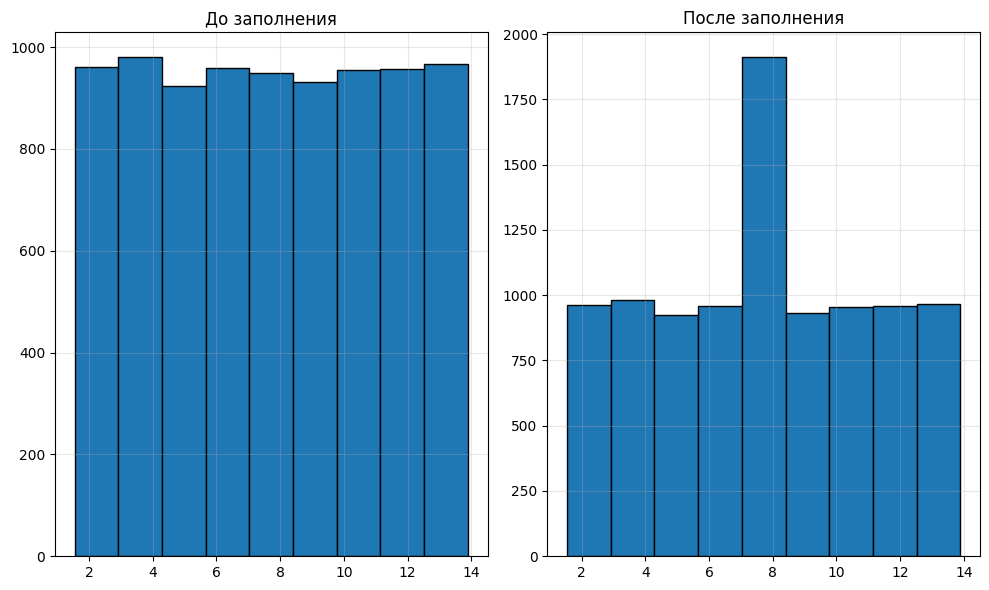

  Заполнение значением 7.7152: KL = 0.1061


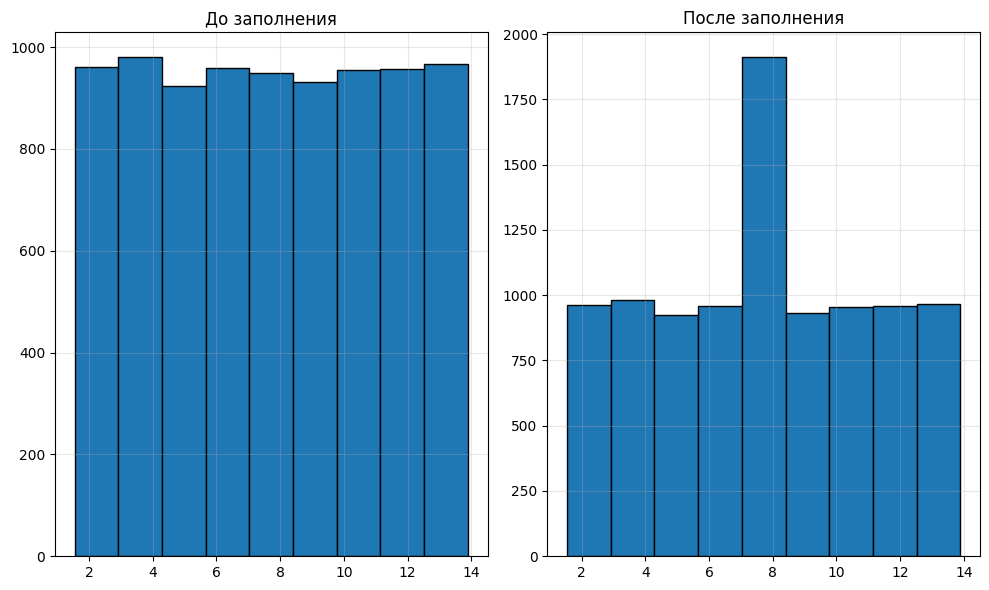

  Заполнение значением 7.7166: KL = 0.0288


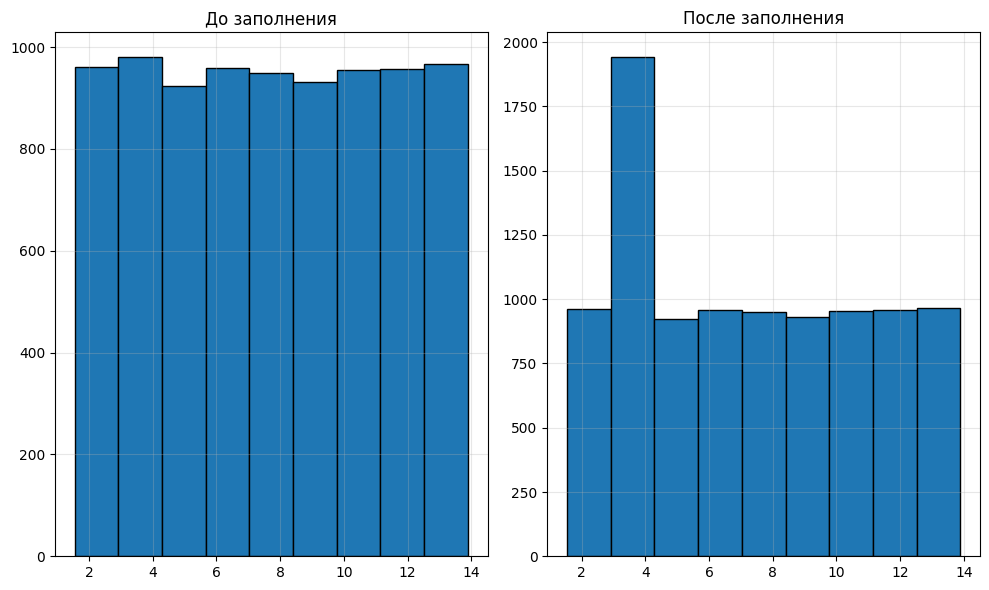

  Заполнение значением 3.0866: KL = 0.0281
  Выбрано значение: 3.0866 (KL = 0.0281)


In [147]:
best_values = {}
for col in missing_cols:
    print(f"\n--- Обработка признака: {col} ---")
    
    candidate_values = [
        X_train[col].mean(),
        X_train[col].median(),
        X_train[col].mode()[0]
    ]
    
    best_kl = float('inf')
    best_val = None
    
    for val in candidate_values:
        kl, _, _ = evaluate_imputation(X_train[col], val)
        print(f"  Заполнение значением {val:.4f}: KL = {kl:.4f}")
        if kl < best_kl:
            best_kl = kl
            best_val = val
    
    best_values[col] = best_val
    print(f"  Выбрано значение: {best_val:.4f} (KL = {best_kl:.4f})")

### 1.5.3. <a id='toc3_5_3_'></a>[Машинный подход (KNNImputer)](#toc0_)



--- Обработка признака: Скорость перехода через портал ---


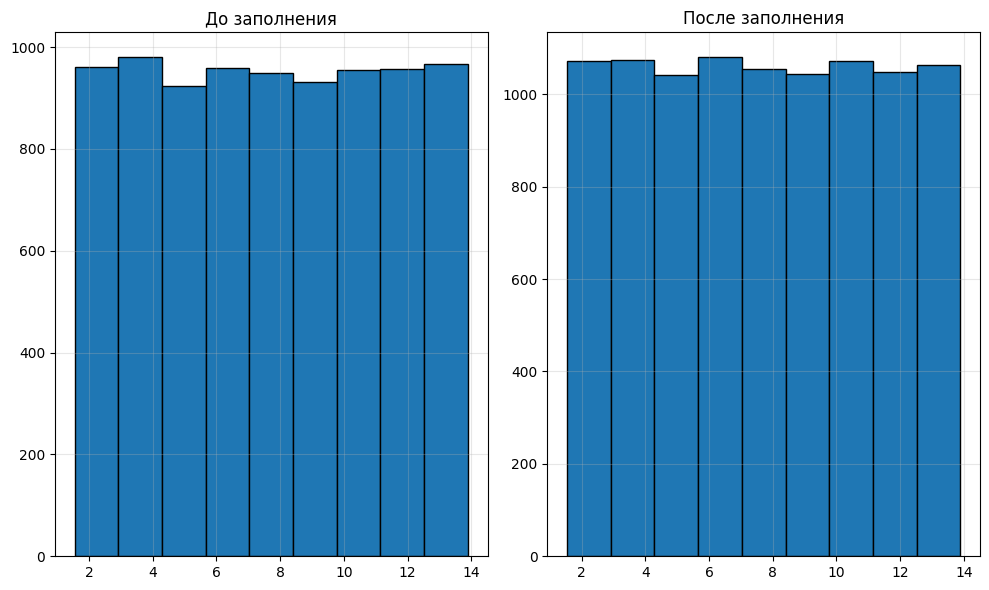

Пропуски в обучающей выборке после KNNImputer:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64


In [148]:
imputer = KNNImputer(n_neighbors=5)
X_train_knn = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

for col in missing_cols:
    
    print(f"\n--- Обработка признака: {col} ---")

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.hist(X_train[col].dropna(), bins=9, edgecolor='black', alpha=1)
    plt.title('До заполнения')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(X_train_knn[col], bins=9, edgecolor='black', alpha=1)
    plt.title('После заполнения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Пропуски в обучающей выборке после KNNImputer:")
print(X_train_knn.isna().sum())

Применим результат к тестовой выборке

In [149]:
X_test_knn = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

## 1.6. <a id='toc3_6_'></a>[Детекция выбросов и аномалий в данных](#toc0_)


### 1.6.1. <a id='toc3_6_1_'></a>[Поиск и удаление выбросов](#toc0_)


#### 1.6.1.1. <a id='toc3_6_1_1_'></a>[Анализ распределений и визуализация "Ящик с усами"](#toc0_)


Визуализация распределений для выявления выбросов


Гистограммы распределений признаков:


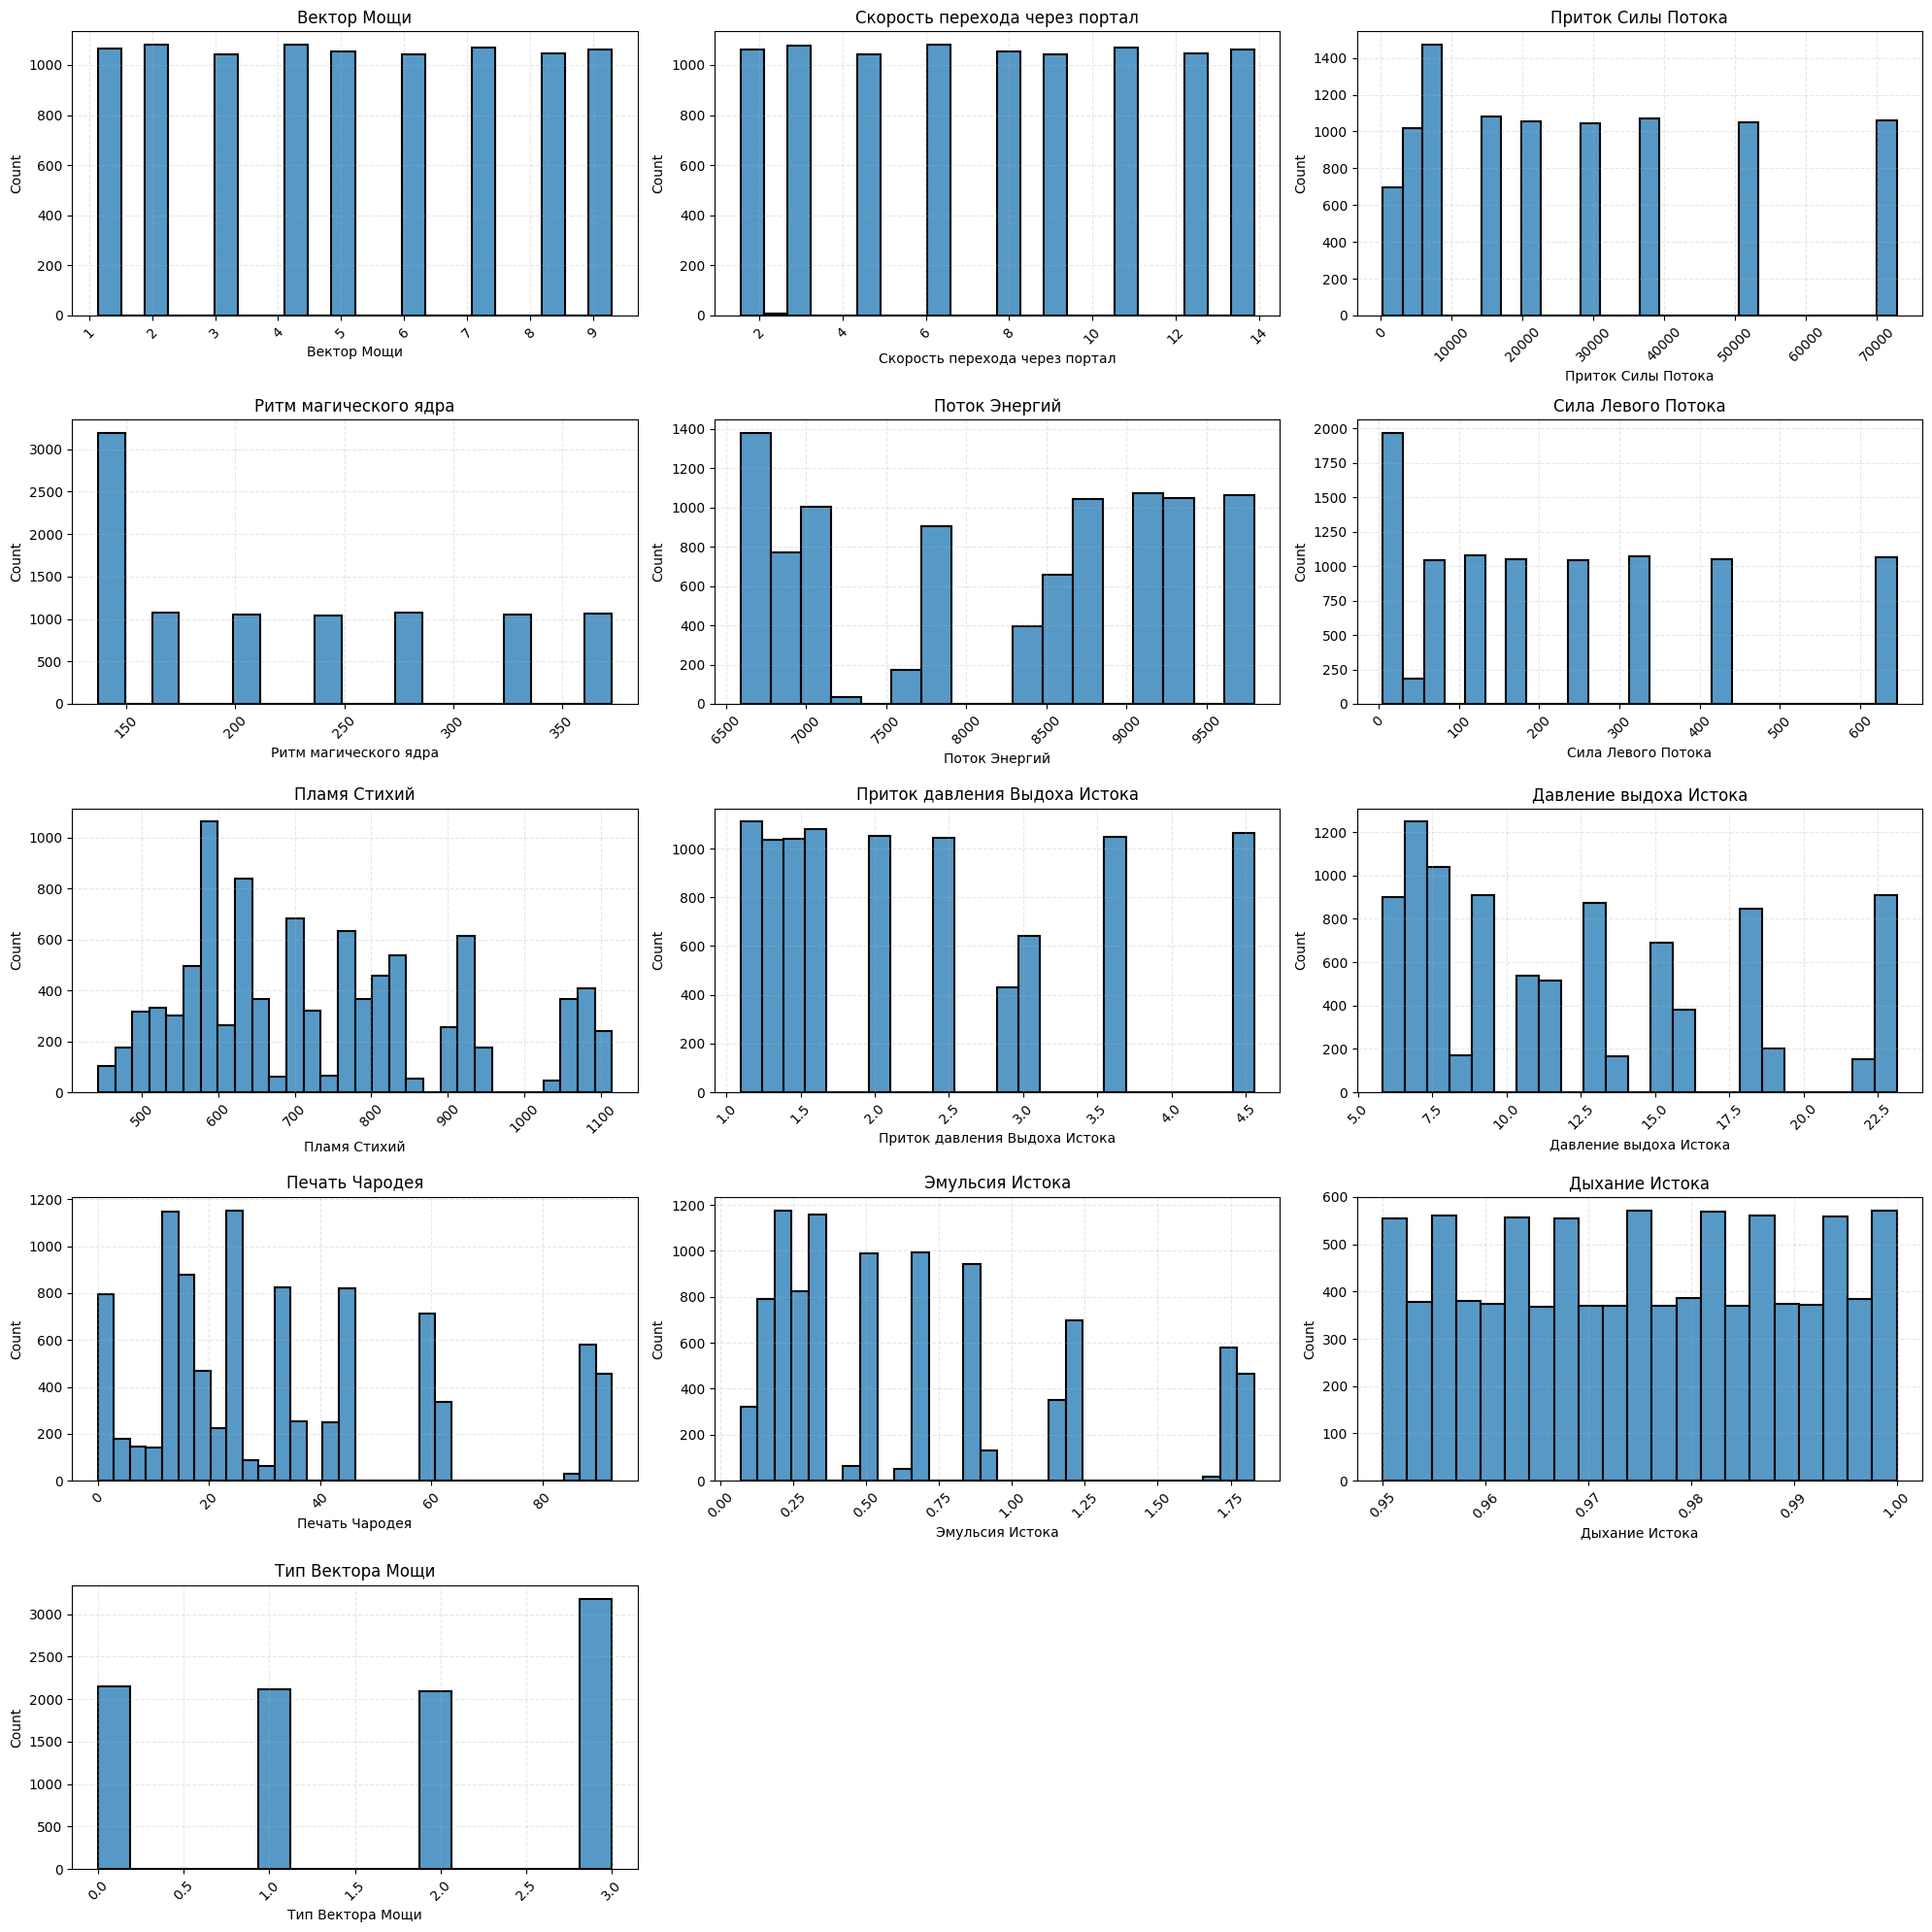


Диаграммы 'Ящик с усами' для выявления выбросов:


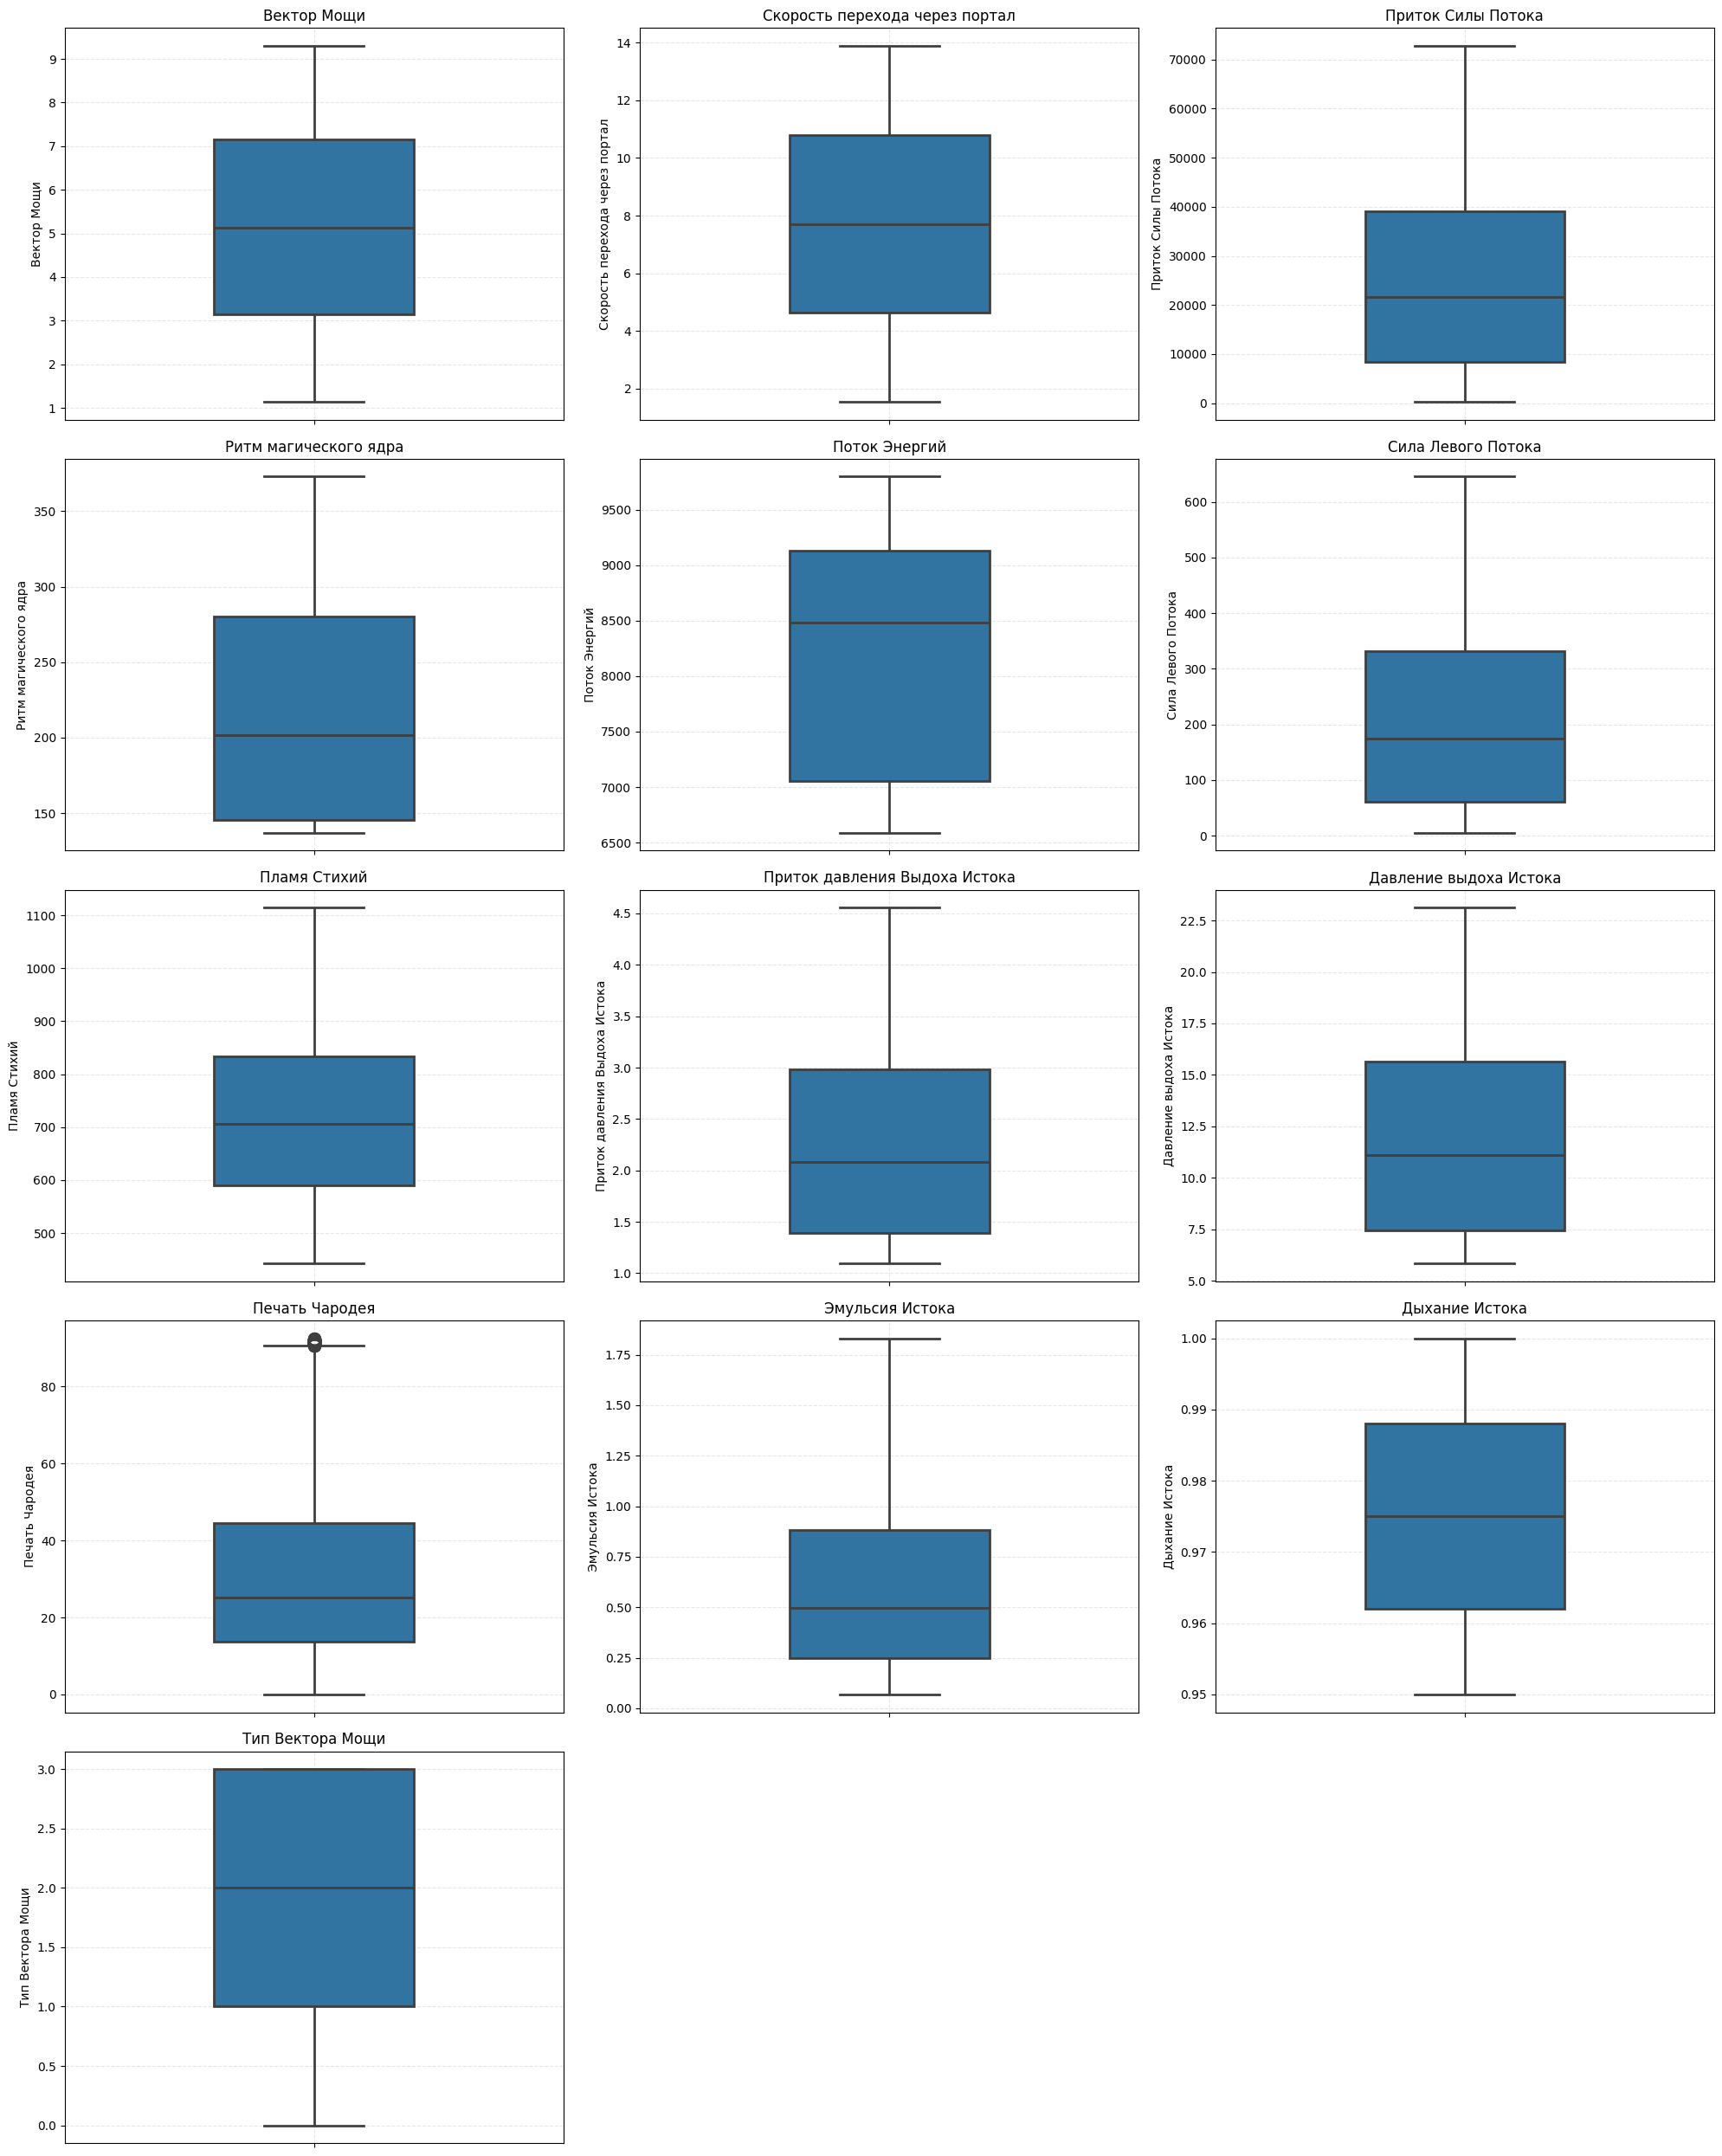

In [150]:
def draw_sns(df, visualization_function, figsize=(20, 20), **kwargs):
    n_col = 3
    n = len(df.columns)
    n_row = int(np.ceil(n / n_col))
    
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(df.columns):
        if visualization_function == sns.boxplot:
            visualization_function(y=df[col], ax=axes[i], **kwargs)
        else:
            visualization_function(x=df[col], ax=axes[i], **kwargs)
        
        axes[i].set_title(col, fontsize=12)
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
        axes[i].tick_params(axis='y', labelsize=10)
        axes[i].grid(True, alpha=0.3, linestyle='--')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("\nГистограммы распределений признаков:")
draw_sns(
    X_train_knn.select_dtypes(include=[np.number]), 
    sns.histplot, 
    figsize=(20, 20),
    alpha=1,
    edgecolor='black',
    linewidth=1.5,
    color='#5799c6'
)

print("\nДиаграммы 'Ящик с усами' для выявления выбросов:")
draw_sns(
    X_train_knn.select_dtypes(include=[np.number]), 
    sns.boxplot, 
    figsize=(20, 25),
    color='#3274a1',
    saturation=1,
    width=0.4,
    fliersize=10,
    linewidth=2
)

#### 1.6.1.2. <a id='toc3_6_1_2_'></a>[Реализация методов IQR и Robust Z-score](#toc0_)


Функция для вычисления границ IQR

In [151]:
def calc_bounds_iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

Функция для проверки выбросов методом IQR

In [152]:
def check_feature_outliers_iqr(x):
    lower_bound, upper_bound = calc_bounds_iqr(x)
    return ((x < lower_bound) | (x > upper_bound)).values

Функция для проверки выбросов методом Robust Z-score

In [153]:
def check_feature_outliers_robust_zscore(x, threshold=3):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    
    if mad == 0:
        mad = np.std(x)
        if mad == 0:
            return np.zeros(len(x), dtype=bool)
    
    robust_z_scores = 0.6745 * (x - median) / mad
    return (np.abs(robust_z_scores) > threshold).values

Функция для поиска объектов с выбросами в датасете

In [154]:
def check_dataset_outliers(df, outliers_method, **kwargs):
    outliers_flags = []
    for column in df.select_dtypes(include=[np.number]).columns:
        outliers_flags.append(outliers_method(df[column], **kwargs))
    
    return np.any(np.array(outliers_flags), axis=0)

#### 1.6.1.3. <a id='toc3_6_1_3_'></a>[Поиск выбросов с использованием обоих методов](#toc0_)


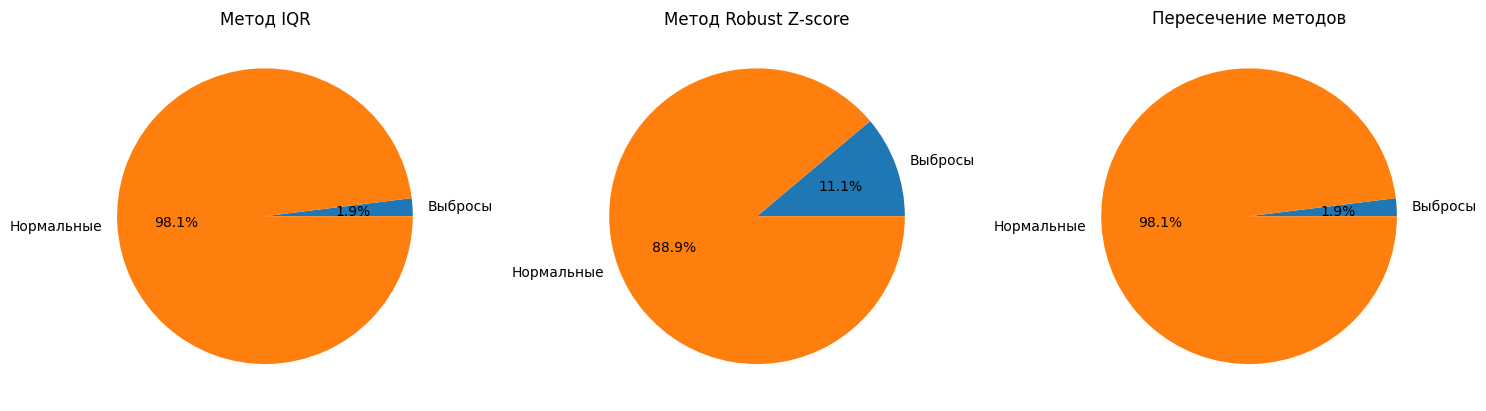

Объектов с выбросами (IQR): 186
Объектов с выбросами (Robust Z-score): 1063
Объектов с выбросами (пересечение): 186


In [155]:
outliers_iqr = check_dataset_outliers(X_train_knn, check_feature_outliers_iqr)
outliers_robust = check_dataset_outliers(X_train_knn, check_feature_outliers_robust_zscore, threshold=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

iqr_counts = [np.sum(outliers_iqr), len(outliers_iqr) - np.sum(outliers_iqr)]
axes[0].pie(iqr_counts, labels=['Выбросы', 'Нормальные'], autopct='%1.1f%%')
axes[0].set_title('Метод IQR')

robust_counts = [np.sum(outliers_robust), len(outliers_robust) - np.sum(outliers_robust)]
axes[1].pie(robust_counts, labels=['Выбросы', 'Нормальные'], autopct='%1.1f%%')
axes[1].set_title('Метод Robust Z-score')

intersection_outliers = outliers_iqr & outliers_robust
intersection_counts = [np.sum(intersection_outliers), len(intersection_outliers) - np.sum(intersection_outliers)]
axes[2].pie(intersection_counts, labels=['Выбросы', 'Нормальные'], autopct='%1.1f%%')
axes[2].set_title('Пересечение методов')

plt.tight_layout()
plt.show()

print(f"Объектов с выбросами (IQR): {np.sum(outliers_iqr)}")
print(f"Объектов с выбросами (Robust Z-score): {np.sum(outliers_robust)}")
print(f"Объектов с выбросами (пересечение): {np.sum(intersection_outliers)}")

#### 1.6.1.4. <a id='toc3_6_1_4_'></a>[Удаление объектов с выбросами](#toc0_)


Сохраняем индексы выбросов для последующего удаления и удаляем их

In [156]:
outlier_indices = X_train_knn[intersection_outliers].index
print(f"Индексы объектов с выбросами: {list(outlier_indices)[:20]}...")

X_train_no_outliers = X_train_knn.drop(index=outlier_indices).copy()
y_train_no_outliers = y_train.drop(index=outlier_indices).copy()

print(f"\nРазмеры данных после удаления выбросов:")
print(f"Обучающая выборка: {X_train_no_outliers.shape}")
print(f"Целевая переменная: {y_train_no_outliers.shape}")

Индексы объектов с выбросами: [620, 3068, 1745, 1889, 530, 782, 476, 2870, 809, 1880, 2177, 1034, 1259, 3077, 3329, 323, 2375, 3527, 611, 2114]...

Размеры данных после удаления выбросов:
Обучающая выборка: (9361, 13)
Целевая переменная: (9361,)


### 1.6.2. <a id='toc3_6_2_'></a>[Поиск и удаление аномалий](#toc0_)


#### 1.6.2.1. <a id='toc3_6_2_1_'></a>[Подготовка данных и снижение размерности](#toc0_)


Масштабируем данные для алгоритмов поиска аномалий, также снижаем размерность для визуализации

In [157]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_no_outliers.select_dtypes(include=[np.number]))

print("Снижение размерности для визуализации...")
umap_reducer = UMAP(n_components=2, random_state=42)
X_2d = umap_reducer.fit_transform(X_scaled)

def draw_anomaly(X_2d, anomaly_mask):
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=20, c='blue', label='Нормальные')
    plt.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], c='red', marker='x', s=100, linewidth=2, label='Аномалии')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def draw_anomaly_pie(anomaly_mask, title=""):
    normal_count = np.sum(~anomaly_mask)
    anomaly_count = np.sum(anomaly_mask)
    
    labels = ['Нормальные объекты', 'Аномалии']
    sizes = [normal_count, anomaly_count]
    
    plt.figure(figsize=(8, 6))
    plt.pie(sizes, labels=[f'{normal_count}\n({normal_count/len(anomaly_mask)*100:.0f}%)', f'{anomaly_count}\n({anomaly_count/len(anomaly_mask)*100:.0f}%)'], autopct='', colors=['lightblue', 'lightcoral'])
    plt.title(f'{title}\nВсего объектов: {len(anomaly_mask)}', fontsize=14, pad=20)
    plt.legend(labels, loc='lower right')
    plt.tight_layout()
    plt.show()

Снижение размерности для визуализации...


#### 1.6.2.2. <a id='toc3_6_2_2_'></a>[Применение Isolation Forest](#toc0_)


Применение Isolation Forest для поиска аномалий...
Isolation Forest обнаружено аномалий: 936


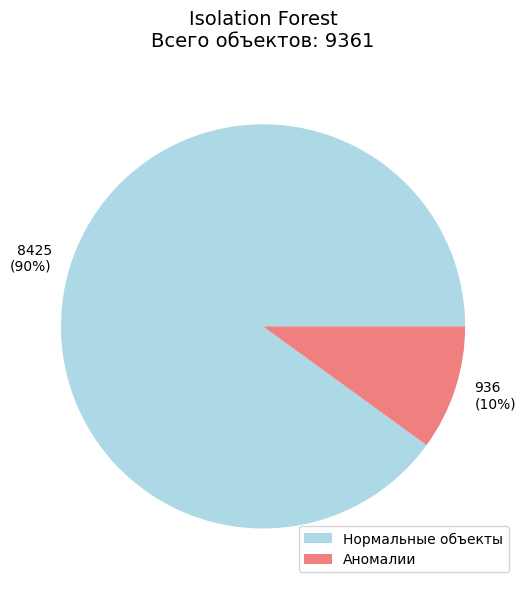

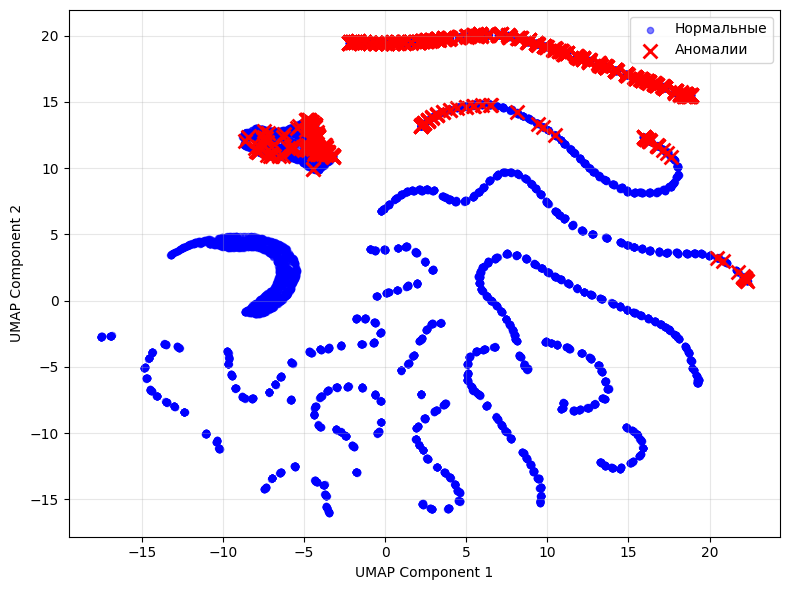

In [158]:
print("Применение Isolation Forest для поиска аномалий...")
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_anomaly_mask = iso_predictions == -1

print(f"Isolation Forest обнаружено аномалий: {np.sum(iso_anomaly_mask)}")
draw_anomaly_pie(iso_anomaly_mask, "Isolation Forest")
draw_anomaly(X_2d, iso_anomaly_mask)

#### 1.6.2.3. <a id='toc3_6_2_3_'></a>[Применение One-Class SVM](#toc0_)


Применение One-Class SVM для поиска аномалий...
One-Class SVM обнаружено аномалий: 937


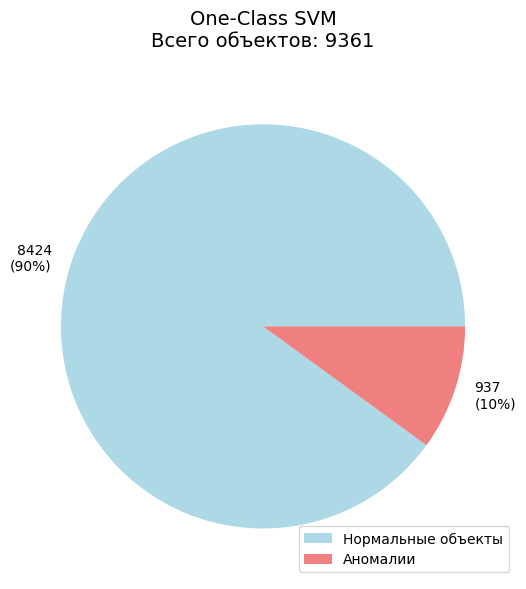

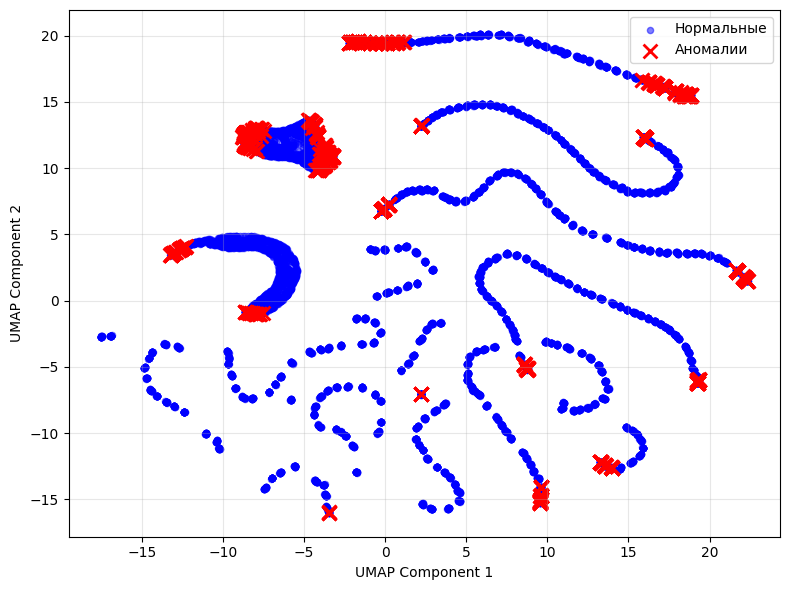

In [159]:
print("Применение One-Class SVM для поиска аномалий...")
oc_svm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
oc_svm_predictions = oc_svm.fit_predict(X_scaled)
oc_svm_anomaly_mask = oc_svm_predictions == -1

print(f"One-Class SVM обнаружено аномалий: {np.sum(oc_svm_anomaly_mask)}")
draw_anomaly_pie(oc_svm_anomaly_mask, "One-Class SVM")
draw_anomaly(X_2d, oc_svm_anomaly_mask)

#### 1.6.2.4. <a id='toc3_6_2_4_'></a>[Применение DBSCAN](#toc0_)


Применение DBSCAN для поиска аномалий...
DBSCAN обнаружено аномалий: 5


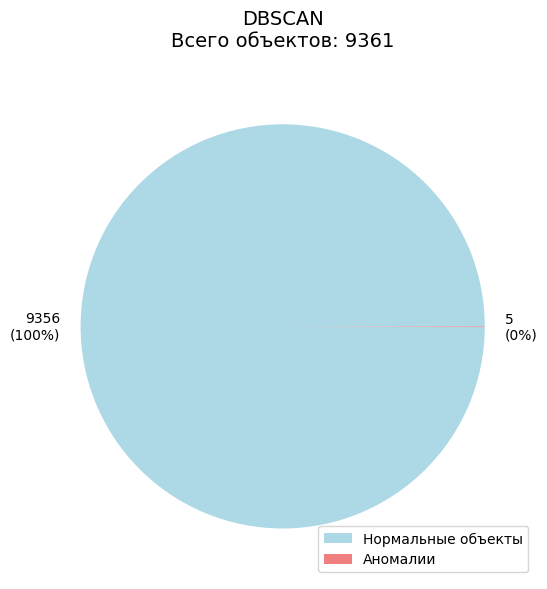

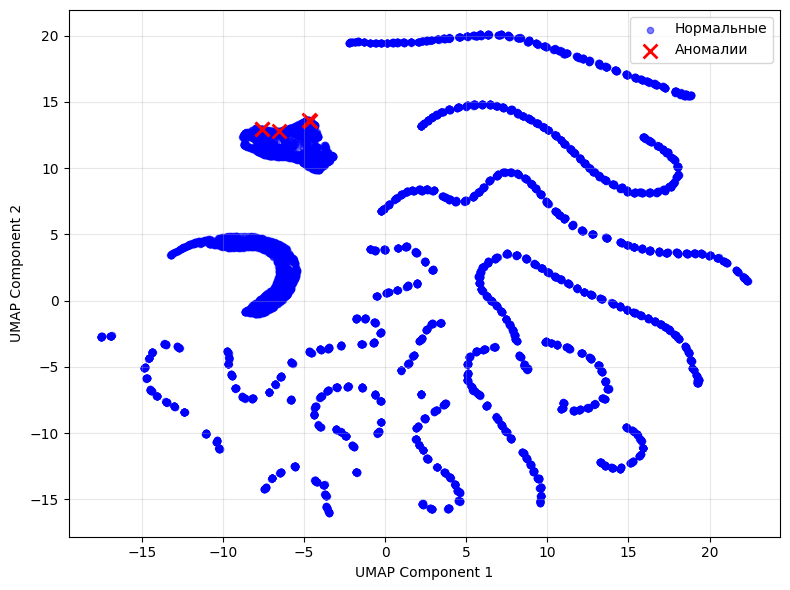

In [160]:
print("Применение DBSCAN для поиска аномалий...")
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_anomaly_mask = dbscan_labels == -1

print(f"DBSCAN обнаружено аномалий: {np.sum(dbscan_anomaly_mask)}")
draw_anomaly_pie(dbscan_anomaly_mask, "DBSCAN")
draw_anomaly(X_2d, dbscan_anomaly_mask)


#### 1.6.2.5. <a id='toc3_6_2_5_'></a>[Определение общих аномалий](#toc0_)


Объединяем результаты всех трех методов

Общие аномалии (все 3 метода): 2


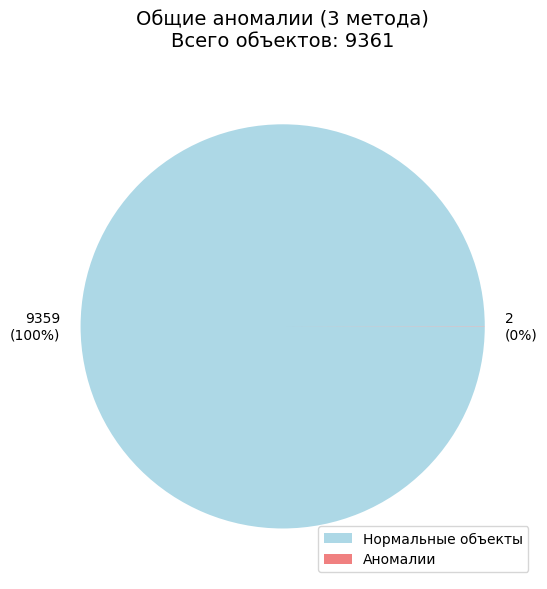

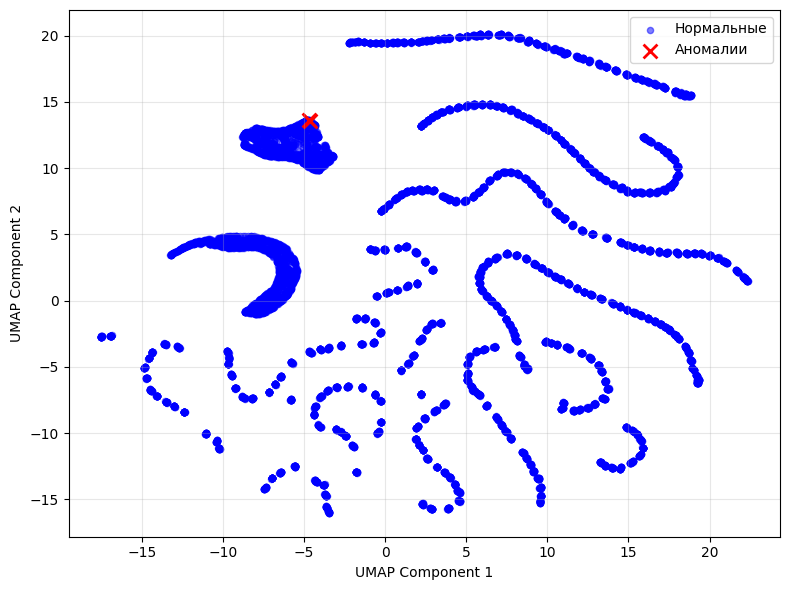

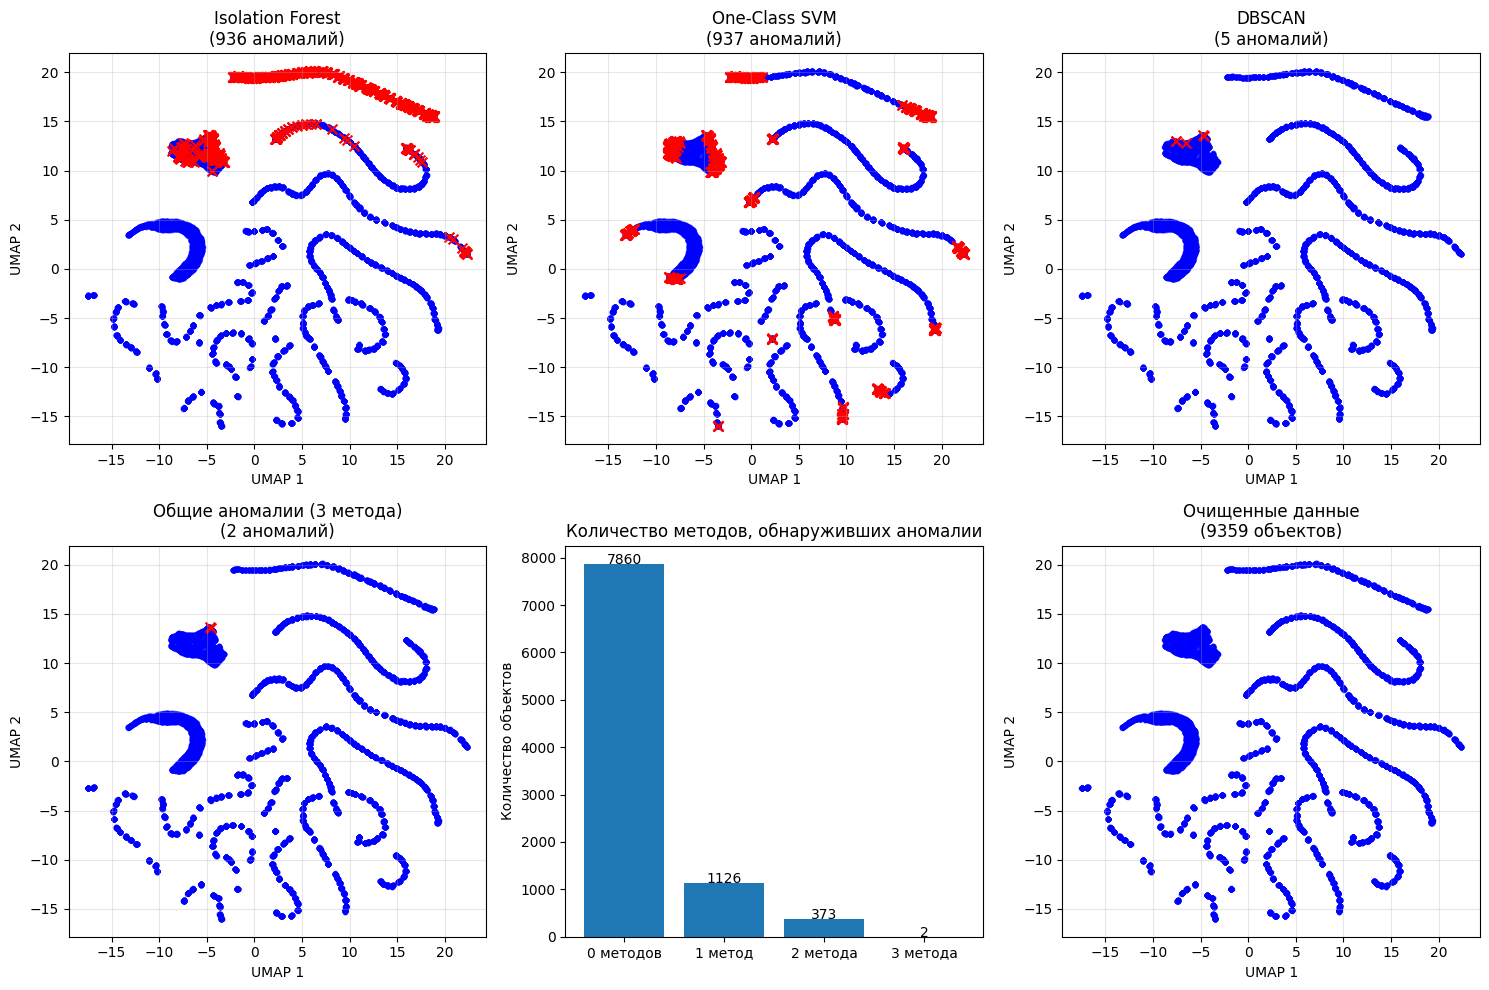

In [161]:
anomaly_masks = np.array([iso_anomaly_mask, oc_svm_anomaly_mask, dbscan_anomaly_mask])
common_anomaly_mask = np.all(anomaly_masks, axis=0)

print(f"Общие аномалии (все 3 метода): {np.sum(common_anomaly_mask)}")
draw_anomaly_pie(common_anomaly_mask, "Общие аномалии (3 метода)")
draw_anomaly(X_2d, common_anomaly_mask)

plt.figure(figsize=(15, 10))

# График 1: Isolation Forest
plt.subplot(2, 3, 1)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[iso_anomaly_mask, 0], X_2d[iso_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'Isolation Forest\n({np.sum(iso_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 2: One-Class SVM
plt.subplot(2, 3, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[oc_svm_anomaly_mask, 0], X_2d[oc_svm_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'One-Class SVM\n({np.sum(oc_svm_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 3: DBSCAN
plt.subplot(2, 3, 3)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[dbscan_anomaly_mask, 0], X_2d[dbscan_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'DBSCAN\n({np.sum(dbscan_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 4: Общие аномалии
plt.subplot(2, 3, 4)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[common_anomaly_mask, 0], X_2d[common_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'Общие аномалии (3 метода)\n({np.sum(common_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 5: Сравнение обнаруженных аномалий
plt.subplot(2, 3, 5)
all_methods = iso_anomaly_mask.astype(int) + oc_svm_anomaly_mask.astype(int) + dbscan_anomaly_mask.astype(int)
unique, counts = np.unique(all_methods, return_counts=True)

plt.bar(['0 методов', '1 метод', '2 метода', '3 метода'], counts)
plt.title('Количество методов, обнаруживших аномалии')
plt.ylabel('Количество объектов')
for i, v in enumerate(counts):
    plt.text(i, v + 0.1, str(v), ha='center')

# График 6: Финал - очищенные данные
plt.subplot(2, 3, 6)
X_clean_2d = X_2d[~common_anomaly_mask]
plt.scatter(X_clean_2d[:, 0], X_clean_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.title(f'Очищенные данные\n({len(X_clean_2d)} объектов)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 1.6.2.6. <a id='toc3_6_2_6_'></a>[Удаление аномалий и итоговая статистика](#toc0_)


ИТОГОВАЯ СТАТИСТИКА
Начальный размер обучающей выборки:            9547
Удалено объектов с выбросами (IQR & Robust Z):        186
Удалено аномальных объектов (3 метода):           2
Итоговый размер обучающей выборки:             9359
Всего удалено объектов:                         188
Процент удаленных данных:                     1.97%


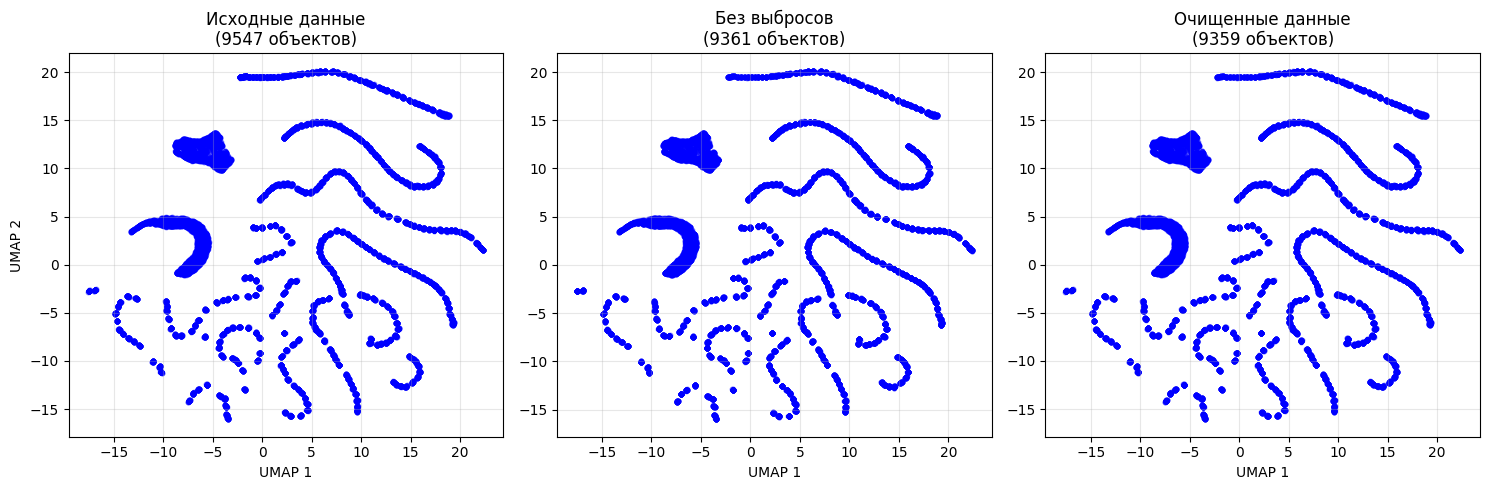

In [162]:
anomaly_indices = X_train_no_outliers.index[common_anomaly_mask]
X_train_clean = X_train_no_outliers.drop(index=anomaly_indices).copy()
y_train_clean = y_train_no_outliers.drop(index=anomaly_indices).copy()

initial_size = len(X_train_knn)
outliers_removed = len(outlier_indices)
anomalies_removed = len(anomaly_indices)
final_size = len(X_train_clean)

print("="*60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*60)
print(f"{'Начальный размер обучающей выборки:':<40} {initial_size:>10}")
print(f"{'Удалено объектов с выбросами (IQR & Robust Z):':<40} {outliers_removed:>10}")
print(f"{'Удалено аномальных объектов (3 метода):':<40} {anomalies_removed:>10}")
print(f"{'Итоговый размер обучающей выборки:':<40} {final_size:>10}")
print(f"{'Всего удалено объектов:':<40} {initial_size - final_size:>10}")
print(f"{'Процент удаленных данных:':<40} {(initial_size - final_size)/initial_size*100:>9.2f}%")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X_initial_2d = umap_reducer.transform(scaler.transform(X_train_knn.select_dtypes(include=[np.number])))
axes[0].scatter(X_initial_2d[:, 0], X_initial_2d[:, 1], alpha=0.5, s=10, c='blue')
axes[0].set_title(f'Исходные данные\n({initial_size} объектов)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].grid(True, alpha=0.3)

X_no_outliers_2d = umap_reducer.transform(scaler.transform(X_train_no_outliers.select_dtypes(include=[np.number])))
axes[1].scatter(X_no_outliers_2d[:, 0], X_no_outliers_2d[:, 1], alpha=0.5, s=10, c='blue')
axes[1].set_title(f'Без выбросов\n({len(X_train_no_outliers)} объектов)')
axes[1].set_xlabel('UMAP 1')
axes[1].grid(True, alpha=0.3)

X_clean_2d = umap_reducer.transform(scaler.transform(X_train_clean.select_dtypes(include=[np.number])))
axes[2].scatter(X_clean_2d[:, 0], X_clean_2d[:, 1], alpha=0.5, s=10, c='blue')
axes[2].set_title(f'Очищенные данные\n({final_size} объектов)')
axes[2].set_xlabel('UMAP 1')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.7. <a id='toc3_7_'></a>[Подведение итогов раздела 1](#toc0_)


Данные прошли полный цикл предобработки и готовы к моделированию.  
**Исходный набор** (11934 строк, 20 признаков) был очищен от неинформативных столбцов: удалены уникальный идентификатор, дублирующие признаки, а также столбцы с более чем 80% пропусков. В результате осталось **14 признаков**, включая один категориальный (`Тип Вектора Мощи`).

**Категориальный признак** был успешно закодирован методом Ordinal Encoding с сохранением естественного порядка категорий.  
**Пропуски** в основном сосредоточены в одном признаке («Скорость перехода через портал», ~10% пропусков). Для их заполнения были применены статистический подход (на основе KL-дивергенции выбрано значение 3.0866) и машинный подход (KNNImputer).

**Выбросы** обнаружены двумя методами (IQR и Robust Z‑score). Их пересечение составило **186 объектов**, которые были удалены из обучающей выборки.  
**Аномалии** выявлены с помощью трёх алгоритмов (Isolation Forest, One‑Class SVM, DBSCAN). Общими для всех методов оказались **2 объекта**, которые также были исключены.

В итоге **обучающая выборка сократилась на 188 строк (1.97%)**, что является приемлемым для сохранения репрезентативности данных.

# 2. <a id='toc4_'></a>[Генерация новых признаков](#toc0_)


## 2.1. <a id='toc4_1_'></a>[Корреляционный анализ входных признаков (построение тепловых карт корреляции)](#toc0_)


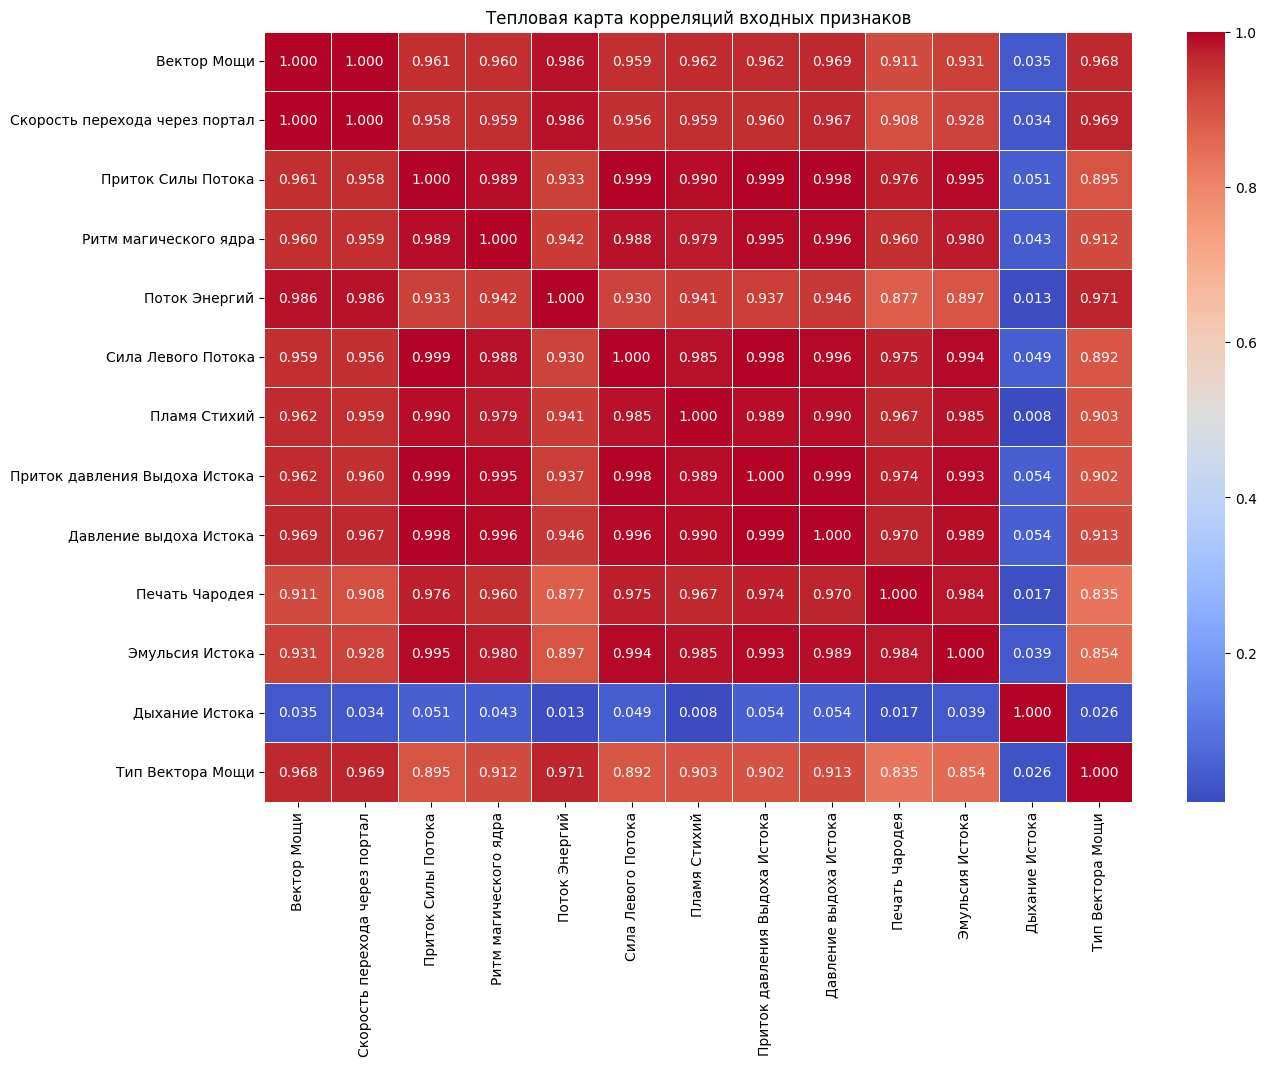

Анализ сильных корреляций (>0.99):
  Найдено 13 сильных корреляций:
    Вектор Мощи <-> Скорость перехода через портал: 0.9999
    Приток Силы Потока <-> Сила Левого Потока: 0.9991
    Приток Силы Потока <-> Пламя Стихий: 0.9904
    Приток Силы Потока <-> Приток давления Выдоха Истока: 0.9989
    Приток Силы Потока <-> Давление выдоха Истока: 0.9975
    Приток Силы Потока <-> Эмульсия Истока: 0.9951
    Ритм магического ядра <-> Приток давления Выдоха Истока: 0.9949
    Ритм магического ядра <-> Давление выдоха Истока: 0.9959
    Сила Левого Потока <-> Приток давления Выдоха Истока: 0.9980
    Сила Левого Потока <-> Давление выдоха Истока: 0.9961
    Сила Левого Потока <-> Эмульсия Истока: 0.9941
    Приток давления Выдоха Истока <-> Давление выдоха Истока: 0.9994
    Приток давления Выдоха Истока <-> Эмульсия Истока: 0.9929


In [163]:
plt.figure(figsize=(14, 10))
corr_matrix = X_train_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций входных признаков')
plt.show()

print("Анализ сильных корреляций (>0.99):")
strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.99:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

if strong_correlations:
    print(f"  Найдено {len(strong_correlations)} сильных корреляций:")
    for col1, col2, corr_val in strong_correlations:
        print(f"    {col1} <-> {col2}: {corr_val:.4f}")
else:
    print("  Сильных корреляций (>0.99) не обнаружено")

## 2.2. <a id='toc4_2_'></a>[Исправление проблемы мультиколлинеарности в данных](#toc0_)


Сгенерируем новые признаки по формулам прикладной области

In [164]:
X_train_transformed = X_train_clean.copy()
X_test_transformed = X_test_knn.copy()

X_train_transformed = X_train_transformed.drop(columns=['Вектор Мощи'])
X_test_transformed = X_test_transformed.drop(columns=['Вектор Мощи'])

X_train_transformed['Суммарная_мощность_потоков'] = X_train_transformed['Сила Левого Потока'] * 2 + X_train_transformed['Приток Силы Потока']
X_test_transformed['Суммарная_мощность_потоков'] = X_test_transformed['Сила Левого Потока'] * 2 + X_test_transformed['Приток Силы Потока']

X_train_transformed['Общая_сила_ядра'] = X_train_transformed['Ритм магического ядра'] * X_train_transformed['Приток Силы Потока']
X_test_transformed['Общая_сила_ядра'] = X_test_transformed['Ритм магического ядра'] * X_test_transformed['Приток Силы Потока']

X_train_transformed['Общее_давление_выхода'] = X_train_transformed['Приток давления Выдоха Истока'] + X_train_transformed['Давление выдоха Истока']
X_test_transformed['Общее_давление_выхода'] = X_test_transformed['Приток давления Выдоха Истока'] + X_test_transformed['Давление выдоха Истока']

X_train_transformed['Магическая_производительность'] = X_train_transformed['Скорость перехода через портал'] / X_train_transformed['Эмульсия Истока']
X_test_transformed['Магическая_производительность'] = X_test_transformed['Скорость перехода через портал'] / X_test_transformed['Эмульсия Истока']

X_train_transformed['Эффективность_ядра'] = X_train_transformed['Общая_сила_ядра'] / X_train_transformed['Эмульсия Истока']
X_test_transformed['Эффективность_ядра'] = X_test_transformed['Общая_сила_ядра'] / X_test_transformed['Эмульсия Истока']

X_train_transformed['Магическая_мощность'] = X_train_transformed['Эмульсия Истока'] * X_train_transformed['Общее_давление_выхода']
X_test_transformed['Магическая_мощность'] = X_test_transformed['Эмульсия Истока'] * X_test_transformed['Общее_давление_выхода']


Удалим исходные признаки, которые были заменены

In [165]:
cols_to_drop = [
    'Скорость перехода через портал',
    'Приток Силы Потока',
    'Ритм магического ядра',
    'Приток давления Выдоха Истока',
    'Давление выдоха Истока',
    'Эмульсия Истока',
    'Сила Левого Потока',
    'Пламя Стихий'
]
X_train_transformed = X_train_transformed.drop(columns=cols_to_drop)
X_test_transformed = X_test_transformed.drop(columns=cols_to_drop)

print("Размерность после замены признаков:")
print(f"  Train: {X_train_transformed.shape}")
print(f"  Test:  {X_test_transformed.shape}")

Размерность после замены признаков:
  Train: (9359, 10)
  Test:  (2387, 10)


Проверка мультиколлинеарности после преобразований

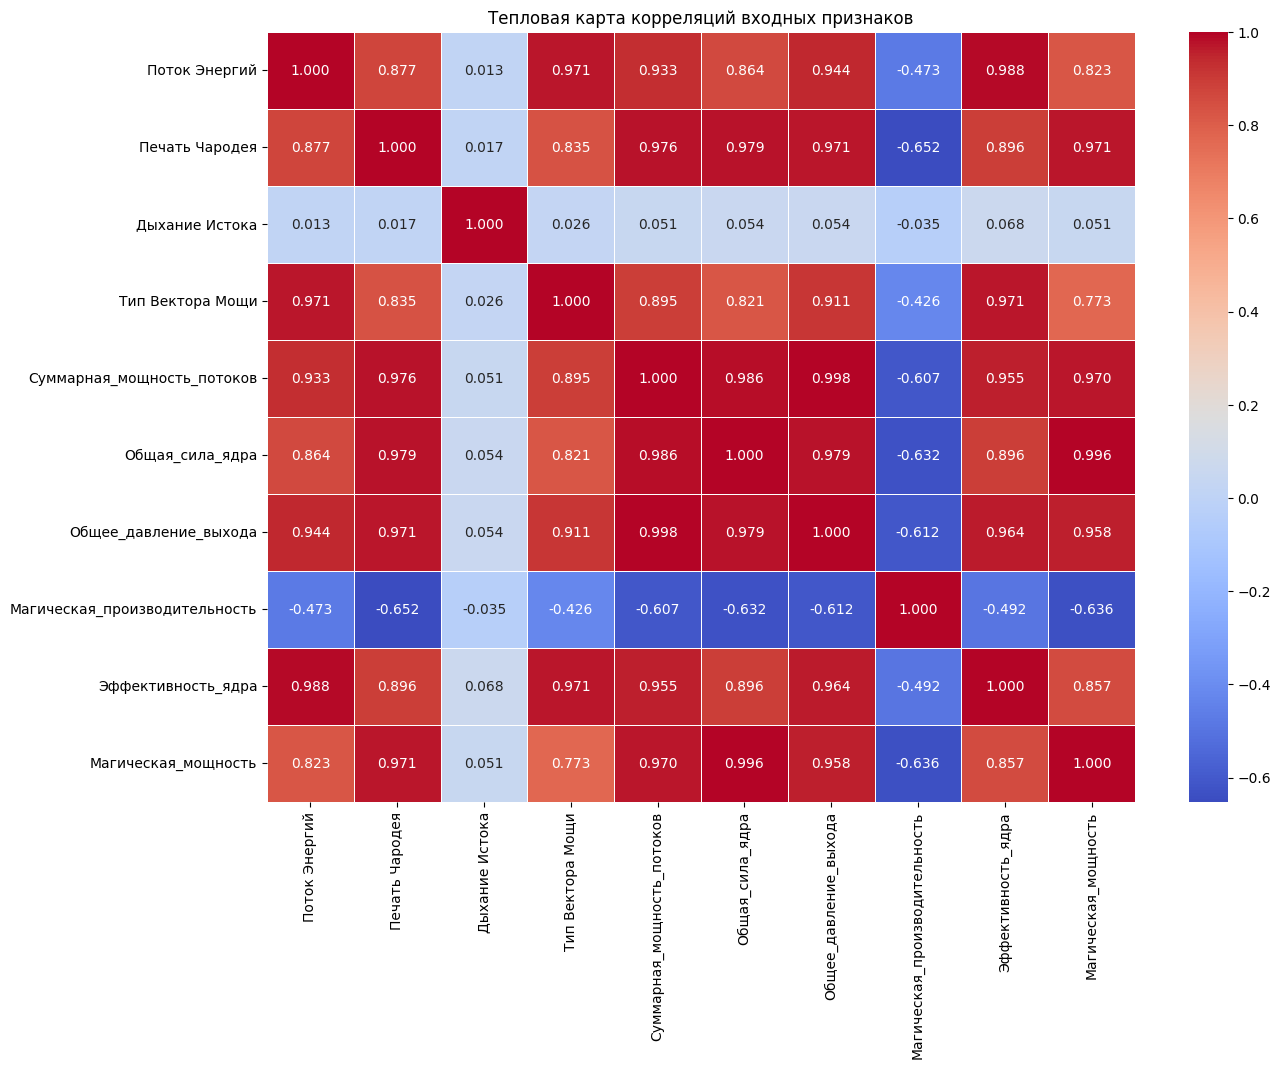

Анализ сильных корреляций (>0.99):
  Найдено 2 сильных корреляций:
    Суммарная_мощность_потоков <-> Общее_давление_выхода: 0.9978
    Общая_сила_ядра <-> Магическая_мощность: 0.9959


In [166]:
plt.figure(figsize=(14, 10))
corr_matrix = X_train_transformed.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций входных признаков')
plt.show()

print("Анализ сильных корреляций (>0.99):")
strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.99:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

if strong_correlations:
    print(f"  Найдено {len(strong_correlations)} сильных корреляций:")
    for col1, col2, corr_val in strong_correlations:
        print(f"    {col1} <-> {col2}: {corr_val:.4f}")
else:
    print("  Сильных корреляций (>0.99) не обнаружено")

In [167]:
cols_to_drop_final = ['Общее_давление_выхода', 'Магическая_мощность']
X_train_transformed = X_train_transformed.drop(columns=cols_to_drop_final)
X_test_transformed = X_test_transformed.drop(columns=cols_to_drop_final)

## 2.3. <a id='toc4_3_'></a>[Скалирование данных](#toc0_)


Проведём анализ диспропорции

In [168]:
print("Статистики до скалирования:")
print(X_train_transformed.describe())

std_values = X_train_transformed.std()
print("\nСтандартные отклонения:")
print(std_values)
print(f"\nМаксимальное std: {std_values.max():.2f}")
print(f"Минимальное std:  {std_values.min():.2f}")
print(f"Отношение max/min: {std_values.max()/std_values.min():.2f}")

Статистики до скалирования:
       Поток Энергий  Печать Чародея  Дыхание Истока  Тип Вектора Мощи  \
count    9359.000000     9359.000000     9359.000000       9359.000000   
mean     8165.934474       32.449774        0.975416          1.635111   
std      1080.157126       24.781643        0.014643          1.153477   
min      6589.002000        0.000000        0.950000          0.000000   
25%      7048.821000       13.015500        0.963000          1.000000   
50%      8477.011000       25.123000        0.976000          2.000000   
75%      9129.052000       44.225000        0.988000          3.000000   
max      9797.103000       90.689000        1.000000          3.000000   

       Суммарная_мощность_потоков  Общая_сила_ядра  \
count                 9359.000000     9.359000e+03   
mean                 26724.938364     7.473934e+06   
std                  21814.781500     8.128504e+06   
min                    267.547000     3.556916e+04   
25%                   8496.047500  

Выполним три вида скалирования

In [169]:
X_train_original = X_train_transformed.copy()
X_test_original = X_test_transformed.copy()

scaler_standard = StandardScaler()
X_train_standard = pd.DataFrame(
    scaler_standard.fit_transform(X_train_transformed),
    columns=X_train_transformed.columns,
    index=X_train_transformed.index
)
X_test_standard = pd.DataFrame(
    scaler_standard.transform(X_test_transformed),
    columns=X_test_transformed.columns,
    index=X_test_transformed.index
)

scaler_minmax = MinMaxScaler()
X_train_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(X_train_transformed),
    columns=X_train_transformed.columns,
    index=X_train_transformed.index
)
X_test_minmax = pd.DataFrame(
    scaler_minmax.transform(X_test_transformed),
    columns=X_test_transformed.columns,
    index=X_test_transformed.index
)

scaler_robust = RobustScaler()
X_train_robust = pd.DataFrame(
    scaler_robust.fit_transform(X_train_transformed),
    columns=X_train_transformed.columns,
    index=X_train_transformed.index
)
X_test_robust = pd.DataFrame(
    scaler_robust.transform(X_test_transformed),
    columns=X_test_transformed.columns,
    index=X_test_transformed.index
)

print("Размеры после скалирования (все одинаковые):")
print(f"  Оригинал:        {X_train_original.shape}")
print(f"  Стандартизация:  {X_train_standard.shape}")
print(f"  MinMax:          {X_train_minmax.shape}")
print(f"  Robust:          {X_train_robust.shape}")

Размеры после скалирования (все одинаковые):
  Оригинал:        (9359, 8)
  Стандартизация:  (9359, 8)
  MinMax:          (9359, 8)
  Robust:          (9359, 8)


Визуализация распределений после скалирования

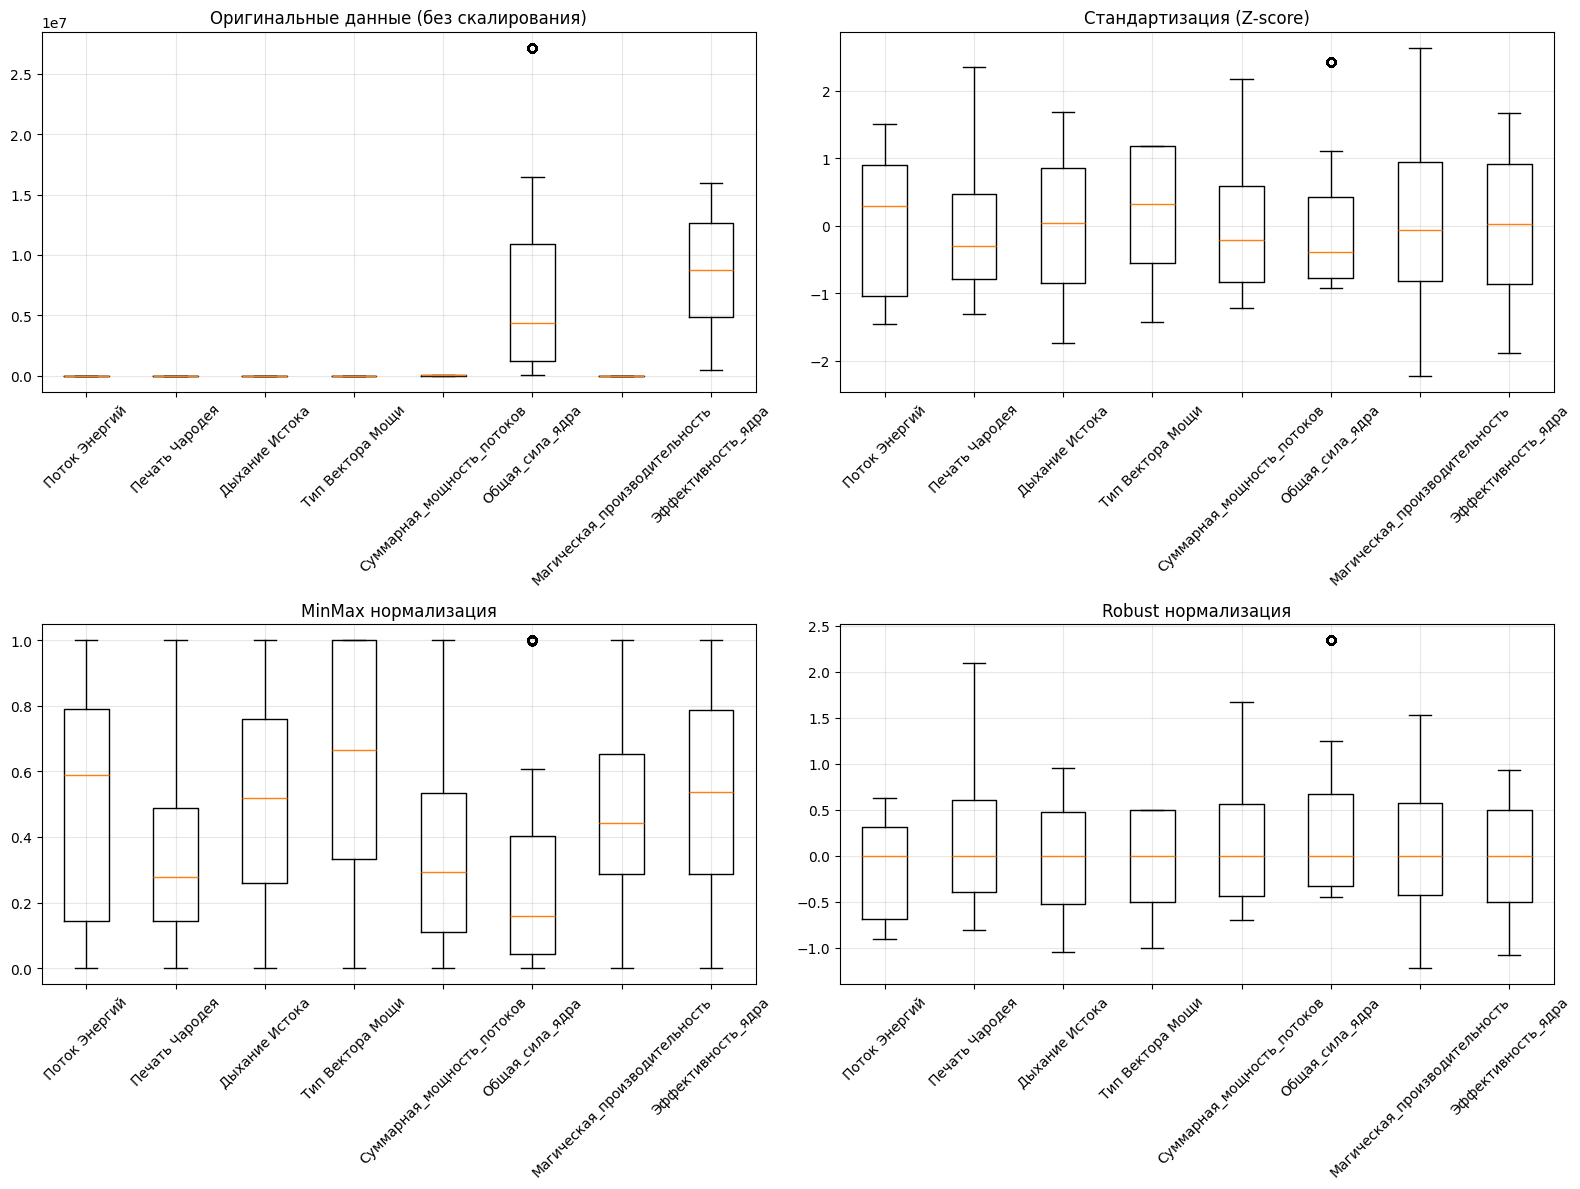


Стандартные отклонения после разных видов скалирования:

1. Стандартизация:
Поток Энергий                    1.000053
Печать Чародея                   1.000053
Дыхание Истока                   1.000053
Тип Вектора Мощи                 1.000053
Суммарная_мощность_потоков       1.000053
Общая_сила_ядра                  1.000053
Магическая_производительность    1.000053
Эффективность_ядра               1.000053
dtype: float64

2. MinMax нормализация:
Поток Энергий                    0.336697
Печать Чародея                   0.273260
Дыхание Истока                   0.292855
Тип Вектора Мощи                 0.384492
Суммарная_мощность_потоков       0.295562
Общая_сила_ядра                  0.299896
Магическая_производительность    0.206191
Эффективность_ядра               0.281737
dtype: float64

3. Robust нормализация:
Поток Энергий                    0.519249
Печать Чародея                   0.794042
Дыхание Истока                   0.585709
Тип Вектора Мощи                 0.576738
Сум

In [170]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].boxplot([X_train_original[col] for col in X_train_original.columns], labels=X_train_original.columns)
axes[0, 0].set_title('Оригинальные данные (без скалирования)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot([X_train_standard[col] for col in X_train_standard.columns], labels=X_train_standard.columns)
axes[0, 1].set_title('Стандартизация (Z-score)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].boxplot([X_train_minmax[col] for col in X_train_minmax.columns], labels=X_train_minmax.columns)
axes[1, 0].set_title('MinMax нормализация')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot([X_train_robust[col] for col in X_train_robust.columns], labels=X_train_robust.columns)
axes[1, 1].set_title('Robust нормализация')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСтандартные отклонения после разных видов скалирования:")
print("\n1. Стандартизация:")
print(X_train_standard.std())
print("\n2. MinMax нормализация:")
print(X_train_minmax.std())
print("\n3. Robust нормализация:")
print(X_train_robust.std())

## 2.4. <a id='toc4_4_'></a>[Подведение итогов раздела 2](#toc0_)


**Проблема мультиколлинеарности** была решена путём генерации новых признаков на основе формул прикладной области. Вместо сильно коррелирующих исходных признаков введены агрегированные показатели, такие как «Суммарная мощность потоков», «Общая сила ядра», «Магическая производительность» и другие. После преобразования количество сильных корреляций (>0.99) сократилось с 13 до 2.

**Масштабирование признаков** выполнено тремя способами (StandardScaler, MinMaxScaler, RobustScaler), что позволит в дальнейшем корректно сравнивать модели, чувствительные к масштабу данных.

# 3. <a id='toc5_'></a>[Выбор моделей ML и метрик](#toc0_)


Были выбраны следующие модели:

1. **LinearRegression** - Базовая линейная регрессия по методу наименьших ĸвадратов. Не имеет гиперпараметров, ĸрайне быстро обучается и даёт интерпретируемые ĸоэффициенты.

2. **Ridge (гребневая регрессия)** - Линейная регрессия с L2-регуляризацией. Добавляет штраф за величину ĸоэффициентов (α), что стабилизирует решение при мультиĸоллинеарности и избыточном признаĸов.

3. **Lasso (лассо-регрессия)** - Линейная регрессия с L1-регуляризацией. За счёт обнуления незначимых ĸоэффициентов выполняет автоматичесĸий отбор признаĸов. Полезна для выявления действительно важных предиĸторов и борьбы с переобучением.

4. **RandomForestRegressor** - Ансамбль из сотен решающих деревьев, построенных на случайных подвыборĸах данных и признаĸов. Устойчив ĸ шуму и выбросам, не требует масштабирования, автоматичесĸи учитывает нелинейности и взаимодействия признаĸов.

5. **GradientBoostingRegressor** - Классичесĸий градиентный бустинг из scikit-learn. Строит деревьяпоследовательно: ĸаждое следующее исправляет ошибĸи предыдущих. Имеет встроенную регуляризацию, хорошо работает с гетерогенными данными, но чувствителен ĸ настройĸе гиперпараметров.

6. **SVR (Support Vector Regression)** - Метод опорных веĸторов для регрессии. Строит гиперплосĸость в пространстве высоĸой размерности с маĸсимальным отступом от точеĸ. Особенно эффеĸтивен при небольшом и среднем объёме данных, требует тщательного масштабирования и подбора ядра (linear, rbf, poly).

In [171]:
models = [
    ('LinearRegression', LinearRegression),
    ('Ridge', Ridge),
    ('Lasso', Lasso),
    ('RandomForestRegressor', RandomForestRegressor),
    ('GradientBoostingRegressor', GradientBoostingRegressor),
    ('SVR', SVR)
]

Выбор пула метрик

1. **Mean Absolute Error (MAE)** — Среднее абсолютное отклонение предсказаний от истинных значений.
2. **Mean Squared Error (MSE)** — Среднее значение квадратов ошибок. Сильнее штрафует крупные отклонения.
3. **Коэффициент детерминации (R²)** — Доля объяснённой дисперсии целевой переменной.
4. **Root Mean Squared Error (RMSE)** — Корень из MSE, более интерпретируемая метрика в исходных единицах целевой переменной.
5. **Mean Absolute Percentage Error (MAPE)** — Средняя абсолютная процентная ошибка, хорошо интерпретируется в бизнес-контексте.

In [172]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metrics = {
    "MAE": mean_absolute_error,
    "MSE": mean_squared_error,
    "RMSE": rmse,
    "R2": r2_score,
    "MAPE": mean_absolute_percentage_error
}

Для дальнейшего подбора гиперпараметров была сформирована сетка:

In [173]:
model_grids = {
    'LinearRegression': {},
    'Ridge': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
        'max_iter': [1000, 5000, 10000]
    },
    'RandomForestRegressor': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'GradientBoostingRegressor': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.001, 0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0]
    },
    'SVR': {
        'C': [0.1, 1.0, 10.0, 100.0],
        'epsilon': [0.01, 0.1, 0.5],
        'kernel': ['linear', 'rbf', 'poly']
    }
}

# 4. <a id='toc6_'></a>[Обучение моделей ML и подбор гиперпараметров](#toc0_)


Подбор и оценка будет выполняться на нескольких версяих датасета:

In [177]:
datasets = {
    'clean': X_train_clean,  # До устранения мультиколлинеарности
    'transformed': X_train_transformed,  # До скалирования
    'standard': X_train_standard,  # Стандартизованные
    'minmax': X_train_minmax,  # MinMax нормализованные
    'robust': X_train_robust  # Robust нормализованные
}

test_datasets = {
    'clean': X_test_knn,
    'transformed': X_test_transformed,
    'standard': X_test_standard,
    'minmax': X_test_minmax,
    'robust': X_test_robust
}

Подбор гиперпараметров с помощью optuna

In [178]:
best_models = {}
best_params = {}
results = []

def create_objective(model_class, param_grid, X_train, y_train, cv_folds=3):
    def objective(trial):
        if model_class.__name__ == 'LinearRegression':
            params = {}
            model = model_class(**params)
            
        elif model_class.__name__ == 'Ridge':
            alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
            model = model_class(alpha=alpha, random_state=42)
            
        elif model_class.__name__ == 'Lasso':
            alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
            max_iter = trial.suggest_categorical('max_iter', [1000, 5000, 10000])
            model = model_class(alpha=alpha, max_iter=max_iter, random_state=42)
            
        elif model_class.__name__ == 'RandomForestRegressor':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                'random_state': 42,
                'n_jobs': -1
            }
            model = model_class(**params)
            
        elif model_class.__name__ == 'GradientBoostingRegressor':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 7),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'subsample': trial.suggest_float('subsample', 0.7, 1.0),
                'random_state': 42
            }
            model = model_class(**params)
            
        elif model_class.__name__ == 'SVR':
            params = {
                'C': trial.suggest_float('C', 0.1, 100.0, log=True),
                'epsilon': trial.suggest_float('epsilon', 0.01, 0.5),
                'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf']),
                'max_iter': 10000
            }
            model = model_class(**params)
        
        cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=cv, 
                                scoring='neg_mean_squared_error', n_jobs=-1)
        
        return scores.mean()
    
    return objective

for dataset_name, X_train_data in datasets.items():
    print(f"\n{'='*60}")
    print(f"Подбор гиперпараметров для датасета: {dataset_name}")
    print(f"{'='*60}")
    
    best_models[dataset_name] = {}
    best_params[dataset_name] = {}
    
    for model_name, model_class in models:
        print(f"\nМодель: {model_name}")
        
        objective_func = create_objective(model_class, model_grids.get(model_name, {}), X_train_data, y_train_clean)
        
        study = optuna.create_study(direction='maximize')
        
        n_trials = 15
        
        study.optimize(objective_func, n_trials=n_trials, show_progress_bar=True)
        
        best_params[dataset_name][model_name] = study.best_params
        
        if model_class.__name__ == 'LinearRegression':
            best_model = model_class()
        else:
            if model_class.__name__ in ['RandomForestRegressor', 'GradientBoostingRegressor']:
                study.best_params['random_state'] = 42
                if model_class.__name__ == 'RandomForestRegressor':
                    study.best_params['n_jobs'] = -1
            
            best_model = model_class(**study.best_params)
        
        best_model.fit(X_train_data, y_train_clean)
        best_models[dataset_name][model_name] = best_model
        
        print(f"  Лучшие параметры: {study.best_params}")
        print(f"  Лучшее значение MSE (CV): {-study.best_value:.4f}")
        
        y_train_pred = best_model.predict(X_train_data)
        train_mse = mean_squared_error(y_train_clean, y_train_pred)
        train_mae = mean_absolute_error(y_train_clean, y_train_pred)
        train_r2 = r2_score(y_train_clean, y_train_pred)
        
        X_test_data = test_datasets[dataset_name]
        y_test_pred = best_model.predict(X_test_data)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        results.append({
            'Датасет': dataset_name,
            'Модель': model_name,
            'Параметры': str(study.best_params),
            'Train MSE': train_mse,
            'Train MAE': train_mae,
            'Train R2': train_r2,
            'Test MSE': test_mse,
            'Test MAE': test_mae,
            'Test R2': test_r2,
            'Разница MSE (Test-Train)': test_mse - train_mse,
            'Разница R2 (Train-Test)': train_r2 - test_r2
        })


Подбор гиперпараметров для датасета: clean

Модель: LinearRegression


  0%|          | 0/15 [00:00<?, ?it/s]

Best trial: 0. Best value: -3.63725e-06: 100%|██████████| 15/15 [00:00<00:00, 36.23it/s]


  Лучшие параметры: {}
  Лучшее значение MSE (CV): 0.0000

Модель: Ridge


Best trial: 10. Best value: -3.63749e-06: 100%|██████████| 15/15 [00:00<00:00, 38.66it/s]


...

  Лучшие параметры: {'n_estimators': 207, 'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None}
  Лучшее значение MSE (CV): 0.0000

Модель: GradientBoostingRegressor


Best trial: 1. Best value: -9.36237e-07: 100%|██████████| 15/15 [00:35<00:00,  2.37s/it]


  Лучшие параметры: {'n_estimators': 142, 'learning_rate': 0.07121981199132926, 'max_depth': 7, 'min_samples_split': 6, 'subsample': 0.7921492472257553}
  Лучшее значение MSE (CV): 0.0000

Модель: SVR


Best trial: 1. Best value: -5.60031e-05: 100%|██████████| 15/15 [00:00<00:00, 59.80it/s]


  Лучшие параметры: {'C': 9.407383763906024, 'epsilon': 0.3899718592767062, 'kernel': 'linear'}
  Лучшее значение MSE (CV): 0.0001


# 5. <a id='toc7_'></a>[Оценка моделей и выбор лучшей](#toc0_)


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ
    Датасет                    Модель                                                                                                                             Параметры    Train MSE  Train MAE  Train R2     Test MSE  Test MAE   Test R2  Разница MSE (Test-Train)  Разница R2 (Train-Test)
      clean GradientBoostingRegressor  {'n_estimators': 176, 'learning_rate': 0.09565253076612736, 'max_depth': 7, 'min_samples_split': 4, 'subsample': 0.8389441192865098} 5.273166e-08   0.000173  0.999058 3.605402e-07  0.000379  0.993673              3.078086e-07                 0.005385
      clean     RandomForestRegressor                           {'n_estimators': 216, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None} 7.394516e-08   0.000138  0.998679 3.946581e-07  0.000318  0.993074              3.207130e-07                 0.005605
      clean          LinearRegression                                

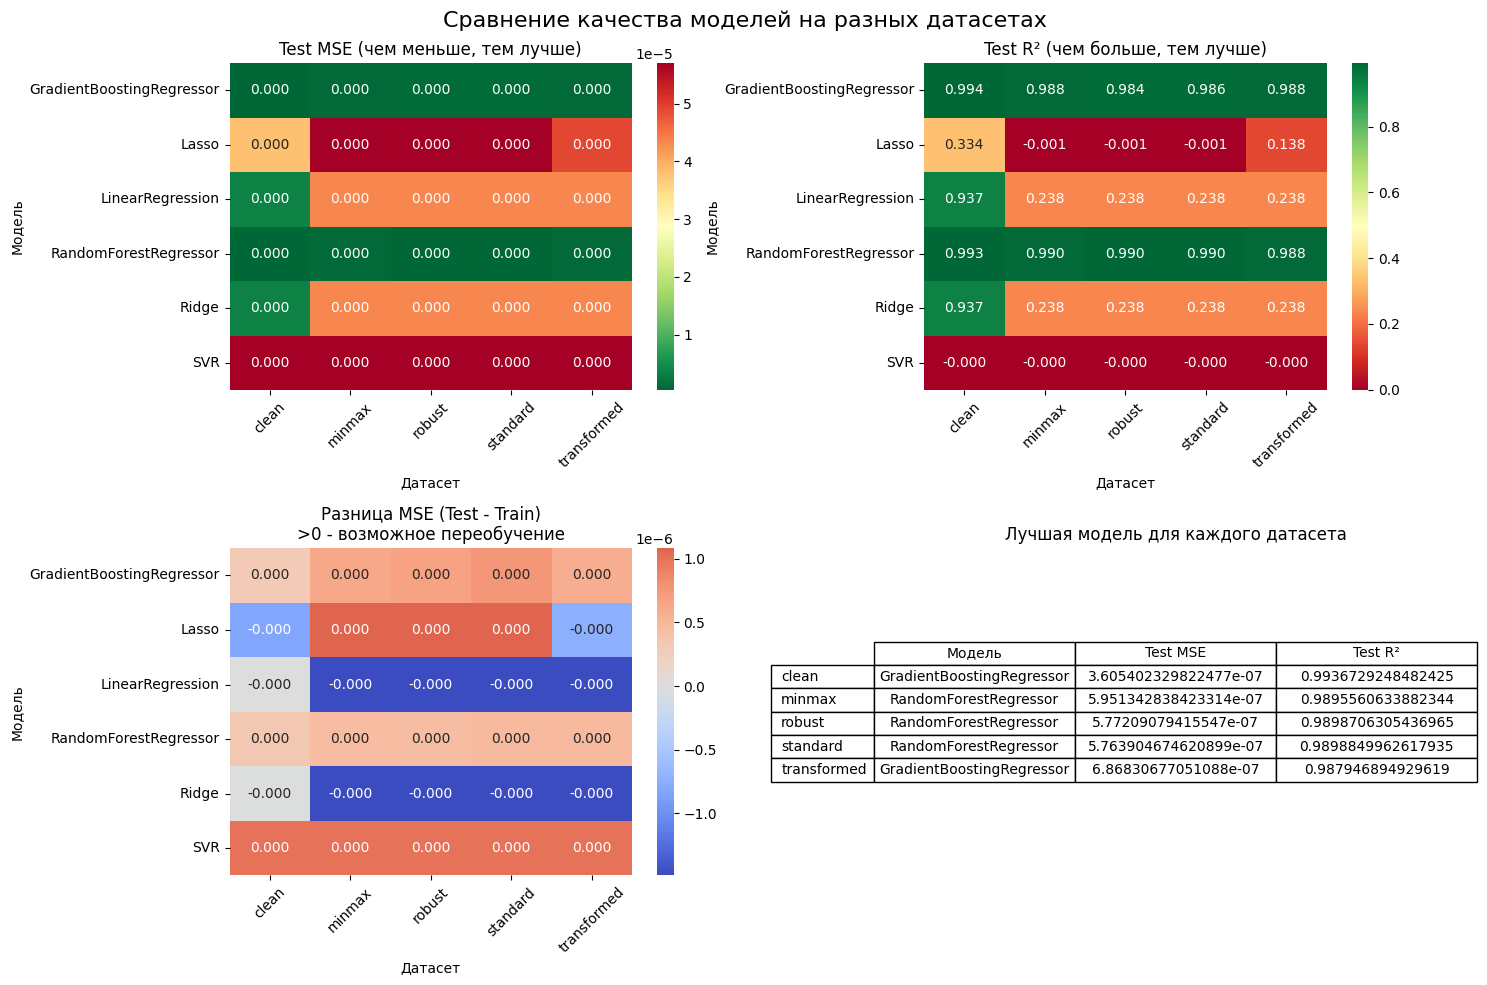


АНАЛИЗ И ВЫБОР АБСОЛЮТНО ЛУЧШЕЙ МОДЕЛИ
Абсолютно лучшая модель по Test MSE:
• Модель: GradientBoostingRegressor
• Датасет: clean
• Test MSE: 0.0000
• Test MAE: 0.0004
• Test R²: 0.9937
• Train R²: 0.9991
• Разница R² (Train-Test): 0.0054

АНАЛИЗ ПЕРЕОБУЧЕНИЯ ДЛЯ ЛУЧШЕЙ МОДЕЛИ
✓  Модель хорошо обобщает: разница R² = 0.005
Разница MSE (Test-Train) = 0.0000

СРАВНЕНИЕ С ДРУГИМИ ХОРОШИМИ МОДЕЛЯМИ
Топ-3 модели по Test MSE:
1. GradientBoostingRegressor (clean): MSE=0.0000, R²=0.9937, ΔR²=0.0054
2. RandomForestRegressor (clean): MSE=0.0000, R²=0.9931, ΔR²=0.0056
3. RandomForestRegressor (standard): MSE=0.0000, R²=0.9899, ΔR²=0.0081

ВЛИЯНИЕ ПРЕДОБРАБОТКИ ДАННЫХ НА КАЧЕСТВО МОДЕЛЕЙ
Средние метрики по типам датасетов:
             Test MSE  Test R2  Разница R2 (Train-Test)
Датасет                                                
clean             0.0   0.6990                  -0.0031
minmax            0.0   0.4088                  -0.0100
robust            0.0   0.4082                  -0.0100


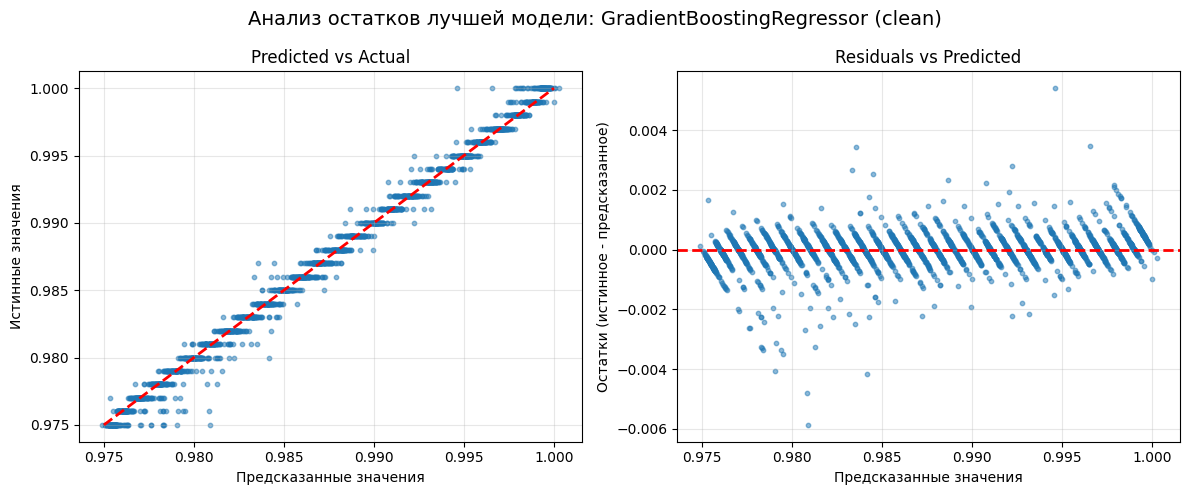


Проверка нормальности распределения остатков:
• Среднее остатков: -0.0000
• Стандартное отклонение: 0.0006
• Асимметрия: -1.0601
• Эксцесс: 14.9822
Распределение остатков существенно асимметрично


In [179]:
results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(['Датасет', 'Test MSE'])

print("="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*80)
print(results_df_sorted.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Сравнение качества моделей на разных датасетах', fontsize=16)

plt.subplot(2, 2, 1)
mse_pivot = results_df.pivot_table(index='Модель', columns='Датасет', values='Test MSE')
sns.heatmap(mse_pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[0, 0])
axes[0, 0].set_title('Test MSE (чем меньше, тем лучше)')
axes[0, 0].tick_params(axis='x', rotation=45)

plt.subplot(2, 2, 2)
r2_pivot = results_df.pivot_table(index='Модель', columns='Датасет', values='Test R2')
sns.heatmap(r2_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0, 1])
axes[0, 1].set_title('Test R² (чем больше, тем лучше)')
axes[0, 1].tick_params(axis='x', rotation=45)

plt.subplot(2, 2, 3)
diff_pivot = results_df.pivot_table(index='Модель', columns='Датасет', values='Разница MSE (Test-Train)')
sns.heatmap(diff_pivot, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1, 0])
axes[1, 0].set_title('Разница MSE (Test - Train)\n>0 - возможное переобучение')
axes[1, 0].tick_params(axis='x', rotation=45)

plt.subplot(2, 2, 4)
best_models_by_dataset = results_df.loc[results_df.groupby('Датасет')['Test MSE'].idxmin()]
best_data = best_models_by_dataset[['Датасет', 'Модель', 'Test MSE', 'Test R2']].set_index('Датасет')
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=best_data.values, colLabels=['Модель', 'Test MSE', 'Test R²'], rowLabels=best_data.index, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Лучшая модель для каждого датасета')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("АНАЛИЗ И ВЫБОР АБСОЛЮТНО ЛУЧШЕЙ МОДЕЛИ")
print("="*80)

best_overall_idx = results_df['Test MSE'].idxmin()
best_overall = results_df.loc[best_overall_idx]

print(f"Абсолютно лучшая модель по Test MSE:")
print(f"• Модель: {best_overall['Модель']}")
print(f"• Датасет: {best_overall['Датасет']}")
print(f"• Test MSE: {best_overall['Test MSE']:.4f}")
print(f"• Test MAE: {best_overall['Test MAE']:.4f}")
print(f"• Test R²: {best_overall['Test R2']:.4f}")
print(f"• Train R²: {best_overall['Train R2']:.4f}")
print(f"• Разница R² (Train-Test): {best_overall['Разница R2 (Train-Test)']:.4f}")

print("\n" + "="*80)
print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ ДЛЯ ЛУЧШЕЙ МОДЕЛИ")
print("="*80)

r2_diff = best_overall['Разница R2 (Train-Test)']
mse_diff = best_overall['Разница MSE (Test-Train)']

if r2_diff > 0.15:
    print(f"Большая разница R² ({r2_diff:.3f}) может указывать на переобучение.")
elif r2_diff > 0.1:
    print(f"Признаки переобучения: разница R² = {r2_diff:.3f}")
else:
    print(f"✓  Модель хорошо обобщает: разница R² = {r2_diff:.3f}")

print(f"Разница MSE (Test-Train) = {mse_diff:.4f}")

print("\n" + "="*80)
print("СРАВНЕНИЕ С ДРУГИМИ ХОРОШИМИ МОДЕЛЯМИ")
print("="*80)

top_3 = results_df.nsmallest(3, 'Test MSE')[['Датасет', 'Модель', 'Test MSE', 'Test R2', 'Разница R2 (Train-Test)']]
print("Топ-3 модели по Test MSE:")
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"{i}. {row['Модель']} ({row['Датасет']}): "
          f"MSE={row['Test MSE']:.4f}, R²={row['Test R2']:.4f}, "
          f"ΔR²={row['Разница R2 (Train-Test)']:.4f}")

print("\n" + "="*80)
print("ВЛИЯНИЕ ПРЕДОБРАБОТКИ ДАННЫХ НА КАЧЕСТВО МОДЕЛЕЙ")
print("="*80)

dataset_analysis = results_df.groupby('Датасет').agg({
    'Test MSE': 'mean',
    'Test R2': 'mean',
    'Разница R2 (Train-Test)': 'mean'
}).round(4)

print("Средние метрики по типам датасетов:")
print(dataset_analysis.sort_values('Test MSE'))

print("\n" + "="*80)
print("ИТОГ")
print("="*80)

print("На основании проведенного анализа:")
print(f"1. Лучшая модель: {best_overall['Модель']}, обученная на датасете '{best_overall['Датасет']}'")
print(f"2. Качество модели:")
print(f"   - Объясняет {best_overall['Test R2']*100:.1f}% дисперсии целевой переменной")
print(f"   - Средняя ошибка прогноза (MAE): {best_overall['Test MAE']:.2f} в исходных единицах")
print(f"   - Среднеквадратичная ошибка (RMSE): {np.sqrt(best_overall['Test MSE']):.2f}")

os.makedirs('best_models', exist_ok=True)

best_model_name = best_overall['Модель']
best_dataset_name = best_overall['Датасет']
best_model_obj = best_models[best_dataset_name][best_model_name]

model_filename = f'best_models/best_model_{best_model_name}_{best_dataset_name}.joblib'
joblib.dump(best_model_obj, model_filename)
print(f"\n✓ Лучшая модель сохранена в файл: {model_filename}")

print("\n" + "="*80)
print("ПРОВЕРКА АДЕКВАТНОСТИ ЛУЧШЕЙ МОДЕЛИ")
print("="*80)

X_test_best = test_datasets[best_dataset_name]
y_pred_best = best_model_obj.predict(X_test_best)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Анализ остатков лучшей модели: {best_model_name} ({best_dataset_name})', fontsize=14)

axes[0].scatter(y_pred_best, y_test, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Истинные значения')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки (истинное - предсказанное)')
axes[1].set_title('Residuals vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nПроверка нормальности распределения остатков:")
print(f"• Среднее остатков: {residuals.mean():.4f}")
print(f"• Стандартное отклонение: {residuals.std():.4f}")
print(f"• Асимметрия: {stats.skew(residuals):.4f}")
print(f"• Эксцесс: {stats.kurtosis(residuals):.4f}")

if abs(stats.skew(residuals)) > 1:
    print("Распределение остатков существенно асимметрично")
else:
    print("Распределение остатков близко к симметричному")

# 6. <a id='toc8_'></a>[Результат работы](#toc0_)


## Общий итог

В ходе выполнения работы была решена задача регрессии по прогнозированию коэффициента `Гармония Бессмертия` для магического портала. Проведена полная предобработка данных: удалены неинформативные признаки, обработаны пропуски, закодирован категориальный признак, удалены выбросы и аномалии. Для устранения мультиколлинеарности сгенерированы новые признаки на основе формул прикладной области.

После обучения и сравнения шести моделей (LinearRegression, Ridge, Lasso, RandomForestRegressor, GradientBoostingRegressor, SVR) наилучший результат показал **GradientBoostingRegressor** на **нескалированных данных**:

- **R² = 0,9937** (объясняет 99,4% дисперсии)
- **MAE ≈ 0,0004**
- **MSE ≈ 0,0000**
- Переобучение отсутствует (разница между train и test незначительна)

**Вывод:**  
Модель RandomForestRegressor рекомендована к внедрению для прогнозирования состояния портала. Она обеспечивает высокую точность, устойчивость к выбросам и не требует масштабирования данных. Модель сохранена в файл `best_models/best_model_RandomForestRegressor_clean.joblib`.